In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import spearmanr, kruskal
import sklearn.feature_selection as skf
import matplotlib.cm as cm

## Import dei vecchi dati

In [2]:
df=pd.read_csv("SH.DataSet(3).csv")


In [3]:
df.keys()

Index(['Fraud', 'amount', 'paymentmethod', 'status', 'fraudmodule',
       'risk_score', 'product'],
      dtype='object')

In [4]:
df

,Fraud,amount,paymentmethod,status,fraudmodule,risk_score,product
0,0,0.00,stripe,Pending,maxmind,86.40,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
1,0,3.74,banktransfer,Cancelled,maxmind,0.22,R9-KVM-VPS-S+
2,0,0.00,stripe,Fraud,maxmind,99.00,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
3,0,0.00,stripe,Fraud,maxmind,99.00,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
4,0,0.00,stripe,Fraud,maxmind,97.63,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
...,...,...,...,...,...,...,...
4609,0,0.00,free,Pending,maxmind,1.23,TS3-FREE
4610,0,0.00,stripe,Fraud,maxmind,99.00,Free 60 Day Trial Web Hosting
4611,0,0.00,free,Pending,maxmind,16.63,MCS - Minecraft 30 day Free Trial
4612,0,6.64,coingate,Active,SKIPPED,0.00,R9-KVM-VPS-S


## Import dei nuovi dati mandati da Marco:

In [5]:
# Specify the file path
file_path = "SHDATA2(1).csv"
# Load the CSV file into a DataFrame
df_new = pd.read_csv(file_path)

In [6]:
df_new

,risk_score,status,amount,Fraud,paymentmethod,fraudmodule,product
0,99.0,Fraud,14.99,0,coingate,maxmind,R9-KVM-VPS-M+ - jedrock.me (14/02/2023 - 13/03...
1,99.0,Fraud,56.99,0,coingate,maxmind,AMD-RYZ-5-3600 (15/02/2023 - 14/03/2023)\r\nTo...
2,99.0,Fraud,35.99,0,coingate,maxmind,R9-KVM-VPS-L - llarnd (15/02/2023 - 14/03/2023...
3,99.0,Fraud,7.99,0,stripe,maxmind,MCS-L (26/02/2023 - 25/03/2023)\r\nServer Loca...
4,99.0,Fraud,22.49,0,stripe,maxmind,R9-KVM-VPS-M++ - zbar (27/02/2023 - 26/03/2023...
...,...,...,...,...,...,...,...
4195,0.0,Active,131.88,0,coingate,SKIPPED,R9-KVM-VPS-S+ - vm-0004gv (22/01/2025 - 21/01/...
4196,0.0,Active,4.99,0,coingate,SKIPPED,R9-KVM-VPS-S+ - vm-0005Ya (24/01/2025 - 23/02/...
4197,0.0,Active,148.75,0,coingate,SKIPPED,Tax stamp affixed on the original document
4198,0.0,Active,91.92,0,stripe,NaN,R9-KVM-VPS-S (28/01/2025 - 27/02/2025)\r\n(Opt...


In [7]:
df_new.columns

Index(['risk_score', 'status', 'amount', 'Fraud', 'paymentmethod',
       'fraudmodule', 'product'],
      dtype='object')

+ Estrazione delle transazioni che hanno valore 1 per la variabile "Fraud":

In [8]:
df_new_one = df_new[df_new["Fraud"] == 1]

In [9]:
len(df_new_one)

11

## Dato che nei vecchi dati vi è un forte sbilanciamento per la variabile "Fraud"(98% per classe 0 e 2% per classe 1), ho deciso di prendere dai vecchi dati solamente le transazioni che hanno valore 1 per questa variabile che sono 11 transazioni:

+ Dato che ii dataset nuovo ha le stesse medesime colonne del dataset vecchio si può procedere con la concatenazione dei 2 dataset

In [10]:
df = pd.concat([df, df_new_one], ignore_index=True)

In [11]:
df

,Fraud,amount,paymentmethod,status,fraudmodule,risk_score,product
0,0,0.00,stripe,Pending,maxmind,86.40,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
1,0,3.74,banktransfer,Cancelled,maxmind,0.22,R9-KVM-VPS-S+
2,0,0.00,stripe,Fraud,maxmind,99.00,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
3,0,0.00,stripe,Fraud,maxmind,99.00,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
4,0,0.00,stripe,Fraud,maxmind,97.63,1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS
...,...,...,...,...,...,...,...
4620,1,115.12,stripe,Active,maxmind,1.68,AMD-RYZ-9-3900X/5900X Setup Fee
4621,1,156.25,stripe,Active,maxmind,0.75,AMD-RYZ-9-3950X/5950X Setup Fee
4622,1,252.87,stripe,Active,maxmind,0.10,Tax stamp affixed on the original document
4623,1,45.00,stripe,Active,NaN,0.00,Upgrade: R9-KVM-VPS-M+ - A0000cp\r\nR9-KVM-VPS...


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4625 entries, 0 to 4624
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fraud          4625 non-null   int64  
 1   amount         4625 non-null   float64
 2   paymentmethod  4625 non-null   object 
 3   status         4625 non-null   object 
 4   fraudmodule    4624 non-null   object 
 5   risk_score     4625 non-null   float64
 6   product        4549 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 253.1+ KB


# 1. ANALISI DEL DATASET

+ Il  nuovo dataset contiene 4625 righe e 7 variabili.

### Conteggio dei duplicati

In [13]:
# Conta il numero di righe duplicate nel DataFrame
num_duplicates = df.duplicated().sum()

print(f"Numero di duplicati nel dataset: {num_duplicates}")

Numero di duplicati nel dataset: 1516


In [14]:
# Conta il numero di righe dove "Fraud" è uguale a 1
fraud_count = (df["Fraud"] == 1).sum()
# Stampa il risultato
print(f"Numero di transazioni fraudolente prima della rimozione dei duplicati: {fraud_count}")

Numero di transazioni fraudolente prima della rimozione dei duplicati: 98


In [15]:
print(f"Il numero di righe prima della rimoazione dei duplicati è {len(df)}")

Il numero di righe prima della rimoazione dei duplicati è 4625


### Rimozione dei duplicati

In [16]:
df = df.drop_duplicates()

In [17]:
# Conta il numero di righe dove "Fraud" è uguale a 1
fraud_count = (df["Fraud"] == 1).sum()
# Stampa il risultato
print(f"Numero di transazioni fraudolente dopo della rimozione dei duplicati: {fraud_count}")

Numero di transazioni fraudolente dopo della rimozione dei duplicati: 85


In [18]:
print(f"Il numero di righe dopo della rimoazione dei duplicati è {len(df)}")

Il numero di righe dopo della rimoazione dei duplicati è 3109


### Percentuale di valori mancanti nel dataset

In [19]:
missing_values = pd.DataFrame({'ratio': round(df.isna().sum() / len(df) * 100,2)})
missing_values

,ratio
Fraud,0.00
amount,0.00
paymentmethod,0.00
status,0.00
fraudmodule,0.03
risk_score,0.00
product,1.93


# 2. ANALISI UNIVARIATA

### In questa sezione vi sono tutte le funzioni utilizzate per la fase esplorativa

In [20]:
def grafico_barre(dataframe, variable, normalize: bool = False):
    if normalize:
        # Calcolo dei valori normalizzati (z-score)
        col_mean = dataframe[variable].mean()
        col_std = dataframe[variable].std()
        normalized = (dataframe[variable] - col_mean) / col_std
        variablCounts_dic = normalized.value_counts()
        x = variablCounts_dic.index
        y = variablCounts_dic.values / len(dataframe[variable])
    else:
        # Conteggio semplice
        variablCounts_dic = dataframe[variable].value_counts().sort_index()  # Conteggi ordinati
        x = variablCounts_dic.index
        y = variablCounts_dic.values / len(dataframe[variable])

    # Creazione del grafico
    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.bar(x, y, width=0.8, edgecolor='white', linewidth=0.7)  # Colore originale

    # Etichette sulle barre
    for bar in bars:
        bar_height = bar.get_height()  # Altezza della barra (valore della y)
        if bar_height > 0:  # Evita di etichettare barre con altezza zero
            ax.text(bar.get_x() + bar.get_width() / 2, 
                    bar_height + 0.01,  # Posizione leggermente sopra la barra
                    f'{bar_height:.2f}',  # Testo (valore y con due decimali)
                    ha='center', va='bottom', fontsize=10, color='black')

    # Etichette e migliorie grafiche
    ax.set_title(f"Distribuzione dei valori per '{variable}'", fontsize=14)
    ax.set_xlabel("Valori normalizzati" if normalize else variable, fontsize=12)
    ax.set_ylabel("Frequenza relativa", fontsize=12)
    plt.xticks(rotation=0, ha='right', fontsize=10)
    
    plt.tight_layout()
    plt.show()


In [21]:
# Funzione per fare il boxplot
def boxplot(dataframe, variable, LogScaleY: bool = False):
    # Creazione della figura
    plt.figure(figsize=(8, 6))
    
    # Creazione del boxplot
    sns.boxplot(y=dataframe[variable], color='skyblue')
    
    # Impostazione della scala logaritmica sull'asse Y, se richiesto
    if LogScaleY:
        plt.yscale('log')
        
        # Creazione dei tick personalizzati sull'asse Y
        min_val = dataframe[variable].min()
        max_val = dataframe[variable].max()
        ticks = np.geomspace(min_val, max_val, num=6)  # Valori logaritmicamente distribuiti
        ticks = np.round(ticks, decimals=2)  # Arrotondare i valori a 2 decimali
        
        # Impostare i tick personalizzati
        plt.yticks(ticks, [f'{tick}' for tick in ticks])
        plt.ylabel(f'{variable} (Log Scale)')
    else:
        plt.ylabel(f'{variable}')
    
    # Aggiunta del titolo
    plt.title(f'Boxplot della Variabile {variable}')
    plt.xlabel('')
    
    # Mostra il grafico
    plt.show()
    
    # Calcolo del numero di outlier
    Q1 = dataframe[variable].quantile(0.25)  # Primo quartile
    Q3 = dataframe[variable].quantile(0.75)  # Terzo quartile
    IQR = Q3 - Q1  # Intervallo interquartile
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = dataframe[(dataframe[variable] < lower_bound) | (dataframe[variable] > upper_bound)]
    num_outliers = len(outliers)
    
    print(f"Numero totale di outliers nella variabile '{variable}': {num_outliers}")

In [22]:
# funzione per fare istogramma e grafico della densità.
def isto_den(dataframe, variable, normalize: bool = False, logScaleX: bool = False):
    # Normalizzazione della variabile, se richiesto
    if normalize:
        col_mean = dataframe[variable].mean()
        col_std = dataframe[variable].std()
        normalized = (dataframe[variable] - col_mean) / col_std
        data = normalized
    else:
        data = dataframe[f'{variable}']

    # Creazione della figura
    plt.figure(figsize=(8, 6))
    
    # Creazione dell'istogramma
    sns.histplot(data, kde=True, bins=20, color='blue', log_scale=(logScaleX, False))
    
    # Impostazione della scala logaritmica
    if logScaleX:
        plt.xscale('log')
        
        # Generazione dei tick logaritmici distribuiti uniformemente
        min_val = data.min()
        max_val = data.max()
        ticks = np.geomspace(min_val, max_val, num=6)  # Tick logaritmici
        
        # Arrotondare i valori per leggibilità
        ticks = np.round(ticks, decimals=2)
        
        # Impostare i tick personalizzati
        plt.xticks(ticks, [f'{tick}' for tick in ticks])
        plt.xlabel(f'{variable} (Log Scale)')
    else:
        plt.xlabel(f'{variable}')
    
    # Aggiunta del titolo e delle etichette
    plt.title('Istogramma con Funzione di Densità')
    plt.ylabel('Frequenza/Densità')
    
    # Mostra il grafico
    plt.show()

In [23]:
# funzione per ritornare le righe che hanno gli outliers
def get_outliers(column_name):
    # Calcolo dei quartili e dell'IQR
    Q1 = df[column_name].quantile(0.25)  # Primo quartile
    Q3 = df[column_name].quantile(0.75)  # Terzo quartile
    IQR = Q3 - Q1  # Intervallo interquartile
    
    # Limiti per identificare gli outlier
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtra i valori che sono outlier
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)][column_name]
    
    return outliers

Come prima fase andiamo ad analizzare ciascuna variabile 

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3109 entries, 0 to 4624
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fraud          3109 non-null   int64  
 1   amount         3109 non-null   float64
 2   paymentmethod  3109 non-null   object 
 3   status         3109 non-null   object 
 4   fraudmodule    3108 non-null   object 
 5   risk_score     3109 non-null   float64
 6   product        3049 non-null   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 194.3+ KB


## fraudmodule

+ Il sistema di rilevamento delle frodi utilizzato (es. maxmind, SKIPPED).

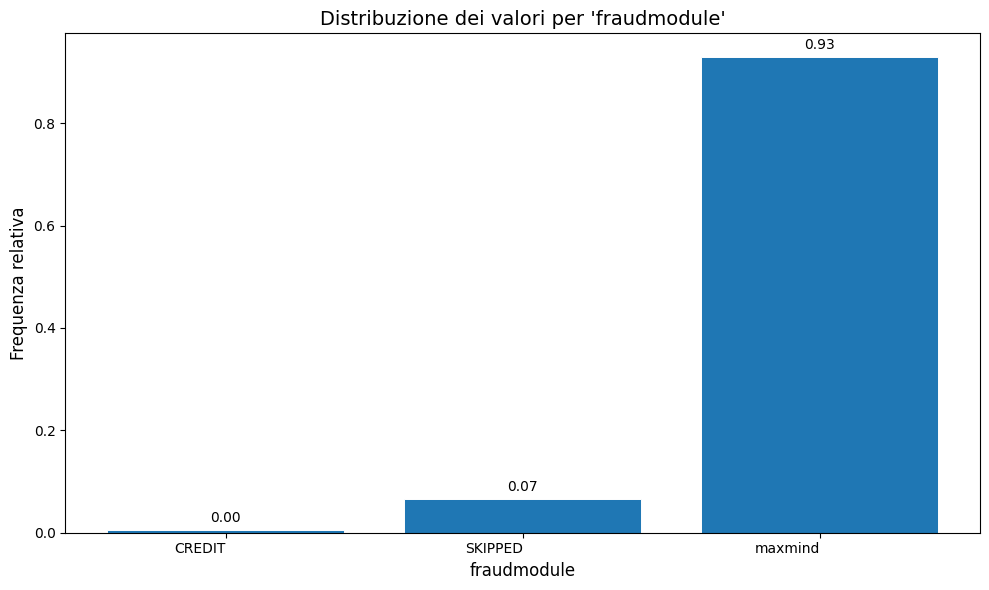

In [25]:
grafico_barre(df, "fraudmodule")

### **Fraud**

+ Indica se la transazione è stata identificata come frode.
+ Valori: 0: Non frode, 1: Frode

In [26]:
df["Fraud"].describe()

count    3109.000000
mean        0.027340
std         0.163098
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: Fraud, dtype: float64

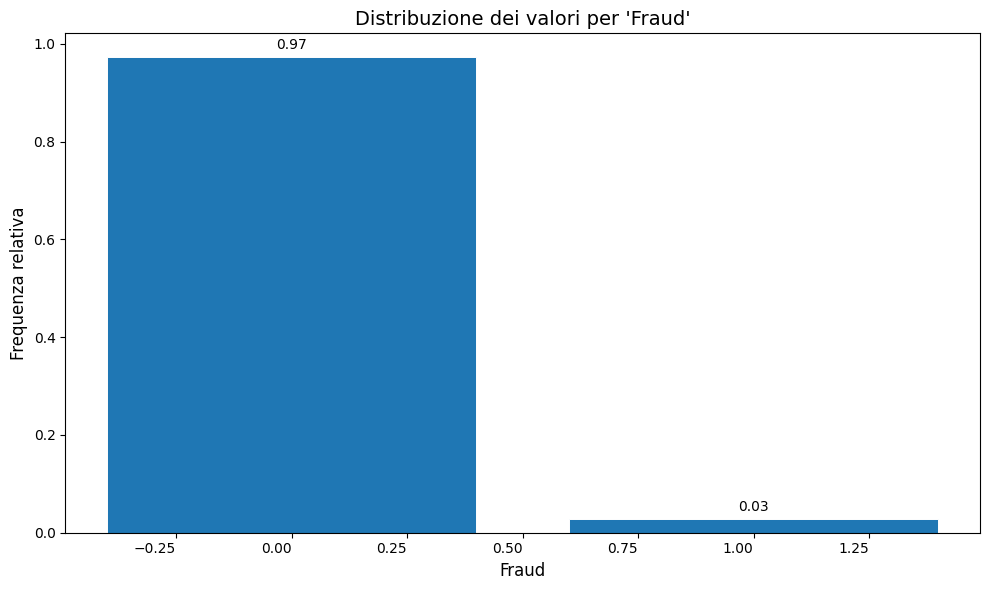

In [27]:
grafico_barre(df,'Fraud')

+ La variabile target "Fraud" risulta essere estremamente sbilanciata

### **Status**

+ Rappresenta lo stato della transazione (es. "Active", "Fraud").

+ Summary statistics di `status`:

In [28]:
df["status"].describe()

count        3109
unique          4
top       Pending
freq         1960
Name: status, dtype: object

+ Grafico a barre della variabile:

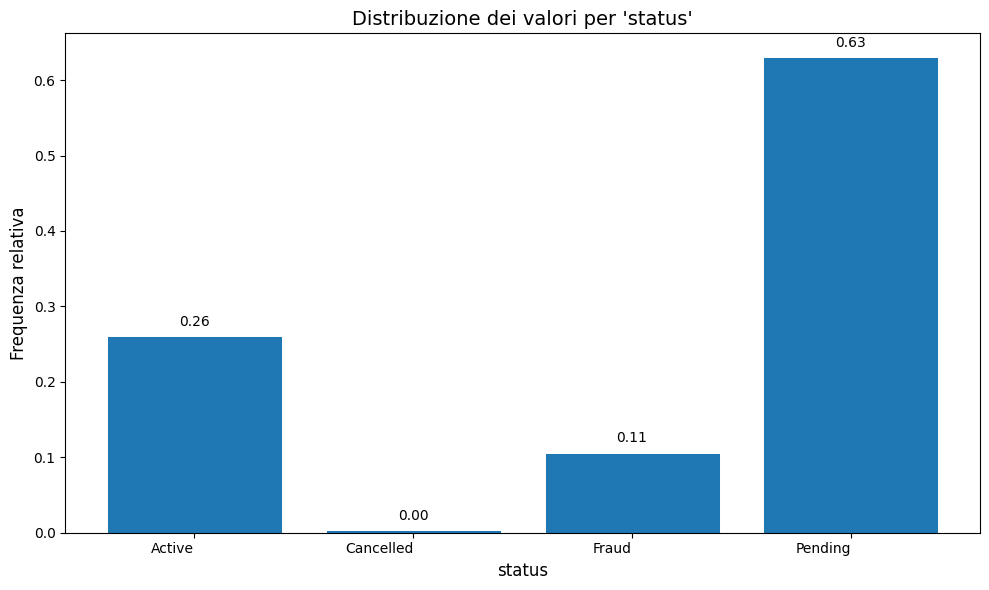

In [29]:
grafico_barre(df,'status')

+ La categoria 'Pending' rappresenta la maggior parte dei dati con una frequenza relativa del 63%, la seconda categoria più comune è 'Active', che rappresenta circa il 26% dei dati, la categoria 'Fraud' è presente solo nell'11% dei casi, la frequenze per la categoria 'Cancelled' è così bassa da essere trascurata

### **fraudmodule**

+ Si riferisce al nome del modulo di rilevamento delle frodi utilizzato {'Maxmind' : software di analisi, 'SKIPPED' : succede quando si tratta non del primo pagamento}

+ Summary statistics della variabile `fraudmodule`:

In [30]:
df["fraudmodule"].describe()

count        3108
unique          3
top       maxmind
freq         2889
Name: fraudmodule, dtype: object

In [31]:
df["fraudmodule"].unique()

array(['maxmind', 'SKIPPED', 'CREDIT', nan], dtype=object)

+ Distribuzione della variabile `fraudmodule`

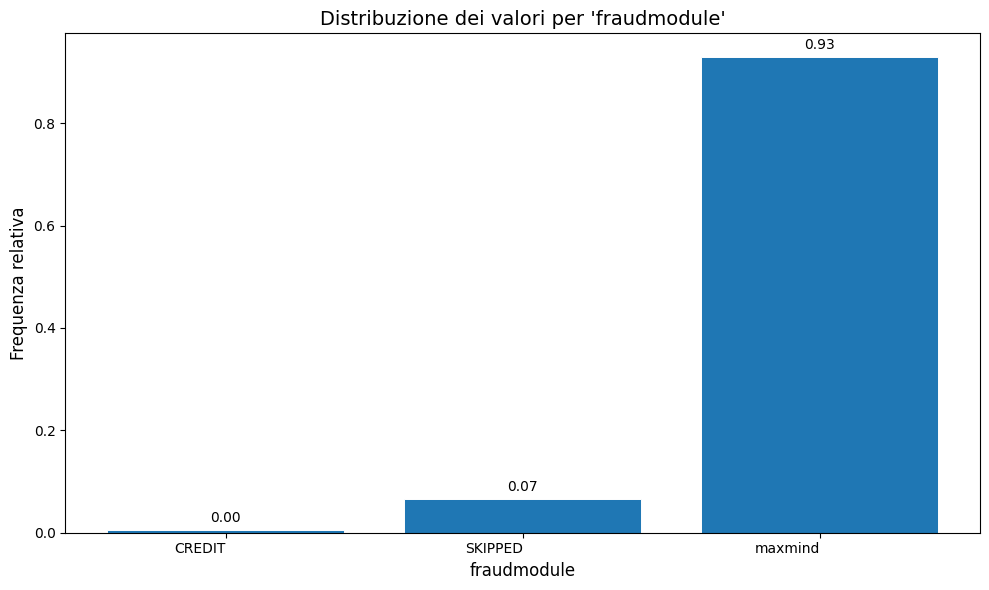

In [32]:
grafico_barre(df, "fraudmodule")

+ Visto che questa variabile assume praticamente una sola modlaità può essere rimossa dal datset

In [33]:
# Rimuove la colonna 'fraudmodule' dal DataFrame
df = df.drop(columns=['fraudmodule'])

### **Amount**

+ Importo della transazione (potrebbe includere valute o altri dettagli).

+ Summary statistics of `amount`:

In [34]:
df["amount"].describe()

count     3109.000000
mean        40.592592
std        363.152695
min          0.000000
25%          0.000000
50%          0.000000
75%          4.600000
max      16754.800000
Name: amount, dtype: float64

+ Boxplot di `amount`:

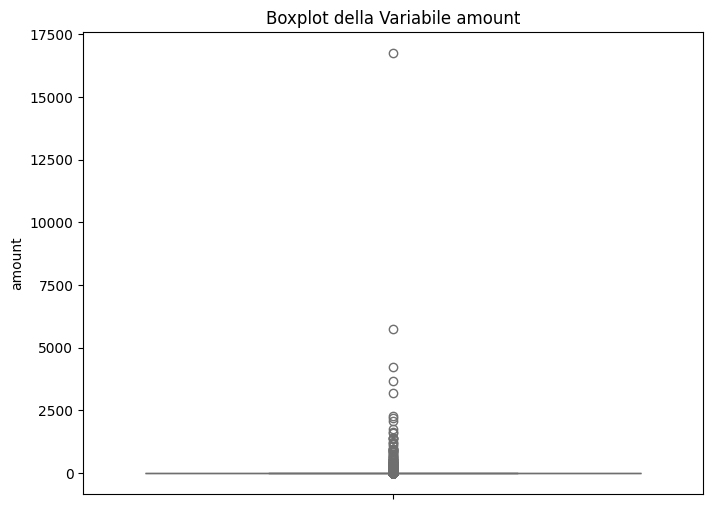

Numero totale di outliers nella variabile 'amount': 549


In [35]:
boxplot(df,"amount")

In [36]:
# Chiamata della funzione per la variabile 'amount'
outliers_amount = get_outliers('amount')
print("Outliers per la variabile 'amount':")
print(outliers_amount)

Outliers per la variabile 'amount':
10       54.89
16       14.57
19       19.99
23      140.75
24      575.00
         ...  
4619    228.87
4620    115.12
4621    156.25
4622    252.87
4623     45.00
Name: amount, Length: 549, dtype: float64


+ Istogramma con funzione di densità

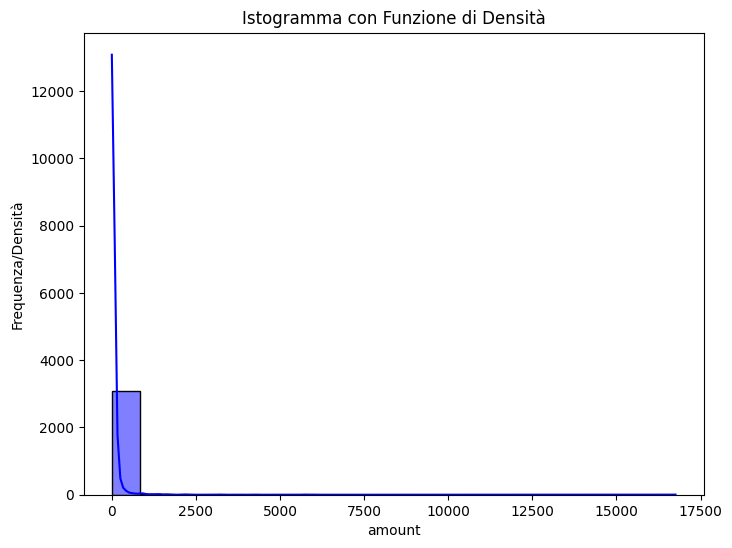

In [37]:
isto_den(df, 'amount')

+ Dai grafici precendenti possiamo osservare che la modalità con cui sono distribuiti suggerisce una forte predominanza di valori piccoli della variabile "amount, con pochi casi con valori molto grandi.

### **Paymentmethod**

+ Summary statistics della variabile `paymentmethod`:

In [38]:
df["paymentmethod"].describe()

count     3109
unique       5
top       free
freq      1502
Name: paymentmethod, dtype: object

+ Valori unici della variabile `paymentmethod`:

In [39]:
df["paymentmethod"].unique()

array(['stripe', 'banktransfer', 'coingate', 'free', 'paypalcheckout'],
      dtype=object)

+ Grafico a barre della variabile `paymentmethod`:

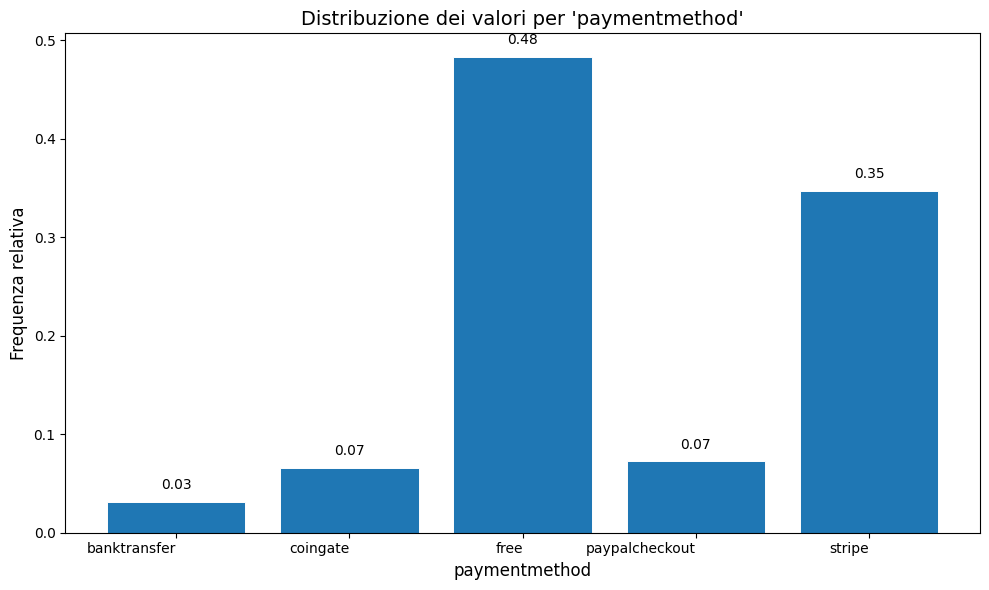

In [40]:
grafico_barre(df, "paymentmethod")

### Product

+ Descrizione: Specifica il prodotto o servizio acquistato nella transazione.

In [41]:
df["product"].unique()

array(['1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS',
       'R9-KVM-VPS-S+', 'R9-KVM-VPS-S',
       'MCS - Minecraft 30 day Free Trial', nan, 'MCS-4GB',
       'R9-KVM-VPS-M+', 'AMD-RYZEN-9-7950X3D', 'TS3-FREE',
       'R9-KVM-VPS-S++', 'AMD-RYZEN-9-7900X3D', 'R9-KVM-VPS-L+',
       'Free 60 Day Trial Web Hosting', 'Weebly Website Builder - Free',
       'INTEL-i9-13900K', 'R9-KVM-VPS-L++', 'INTEL-i7-6700',
       'R9-KVM-VPS-M', 'TS3-1GB', 'R9-KVM-VPS-L', 'INTEL-i7-13700K',
       'WEB HOSTING CPANEL CWP-S', 'AMD-RYZEN-7-3700X',
       'AMD-RYZEN-9-3950X/5950X', 'AMD-RYZEN-9-3900X/5900X', 'DBH-1GB',
       'MCS-1.5GB', 'WEB HOSTING CPANEL CWP-XL', 'R9-KVM-VPS-M++',
       'INTEL-i5-6500', 'TS3-2GB', 'WEB HOSTING CPANEL CWP-M',
       'WEB HOSTING CPANEL CWP-L', 'DAYZ-1.5GB', 'FIVEM-1.5GB',
       'RSLR9-KVM-S', 'MCS-2GB', 'INTEL-i9-9900', 'BGP Session',
       'MCS-6GB', 'Cloud Startup', 'FULLY MANAGED SUPPORT',
       'RSLR9-KVM-XL', 'FIVEM-16GB', 'TS3-4GB', 'MCS-8GB', 'TS3-6G

In [42]:
df["product"].describe()

count         3049
unique          56
top       TS3-FREE
freq          1214
Name: product, dtype: object

) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\mmona\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


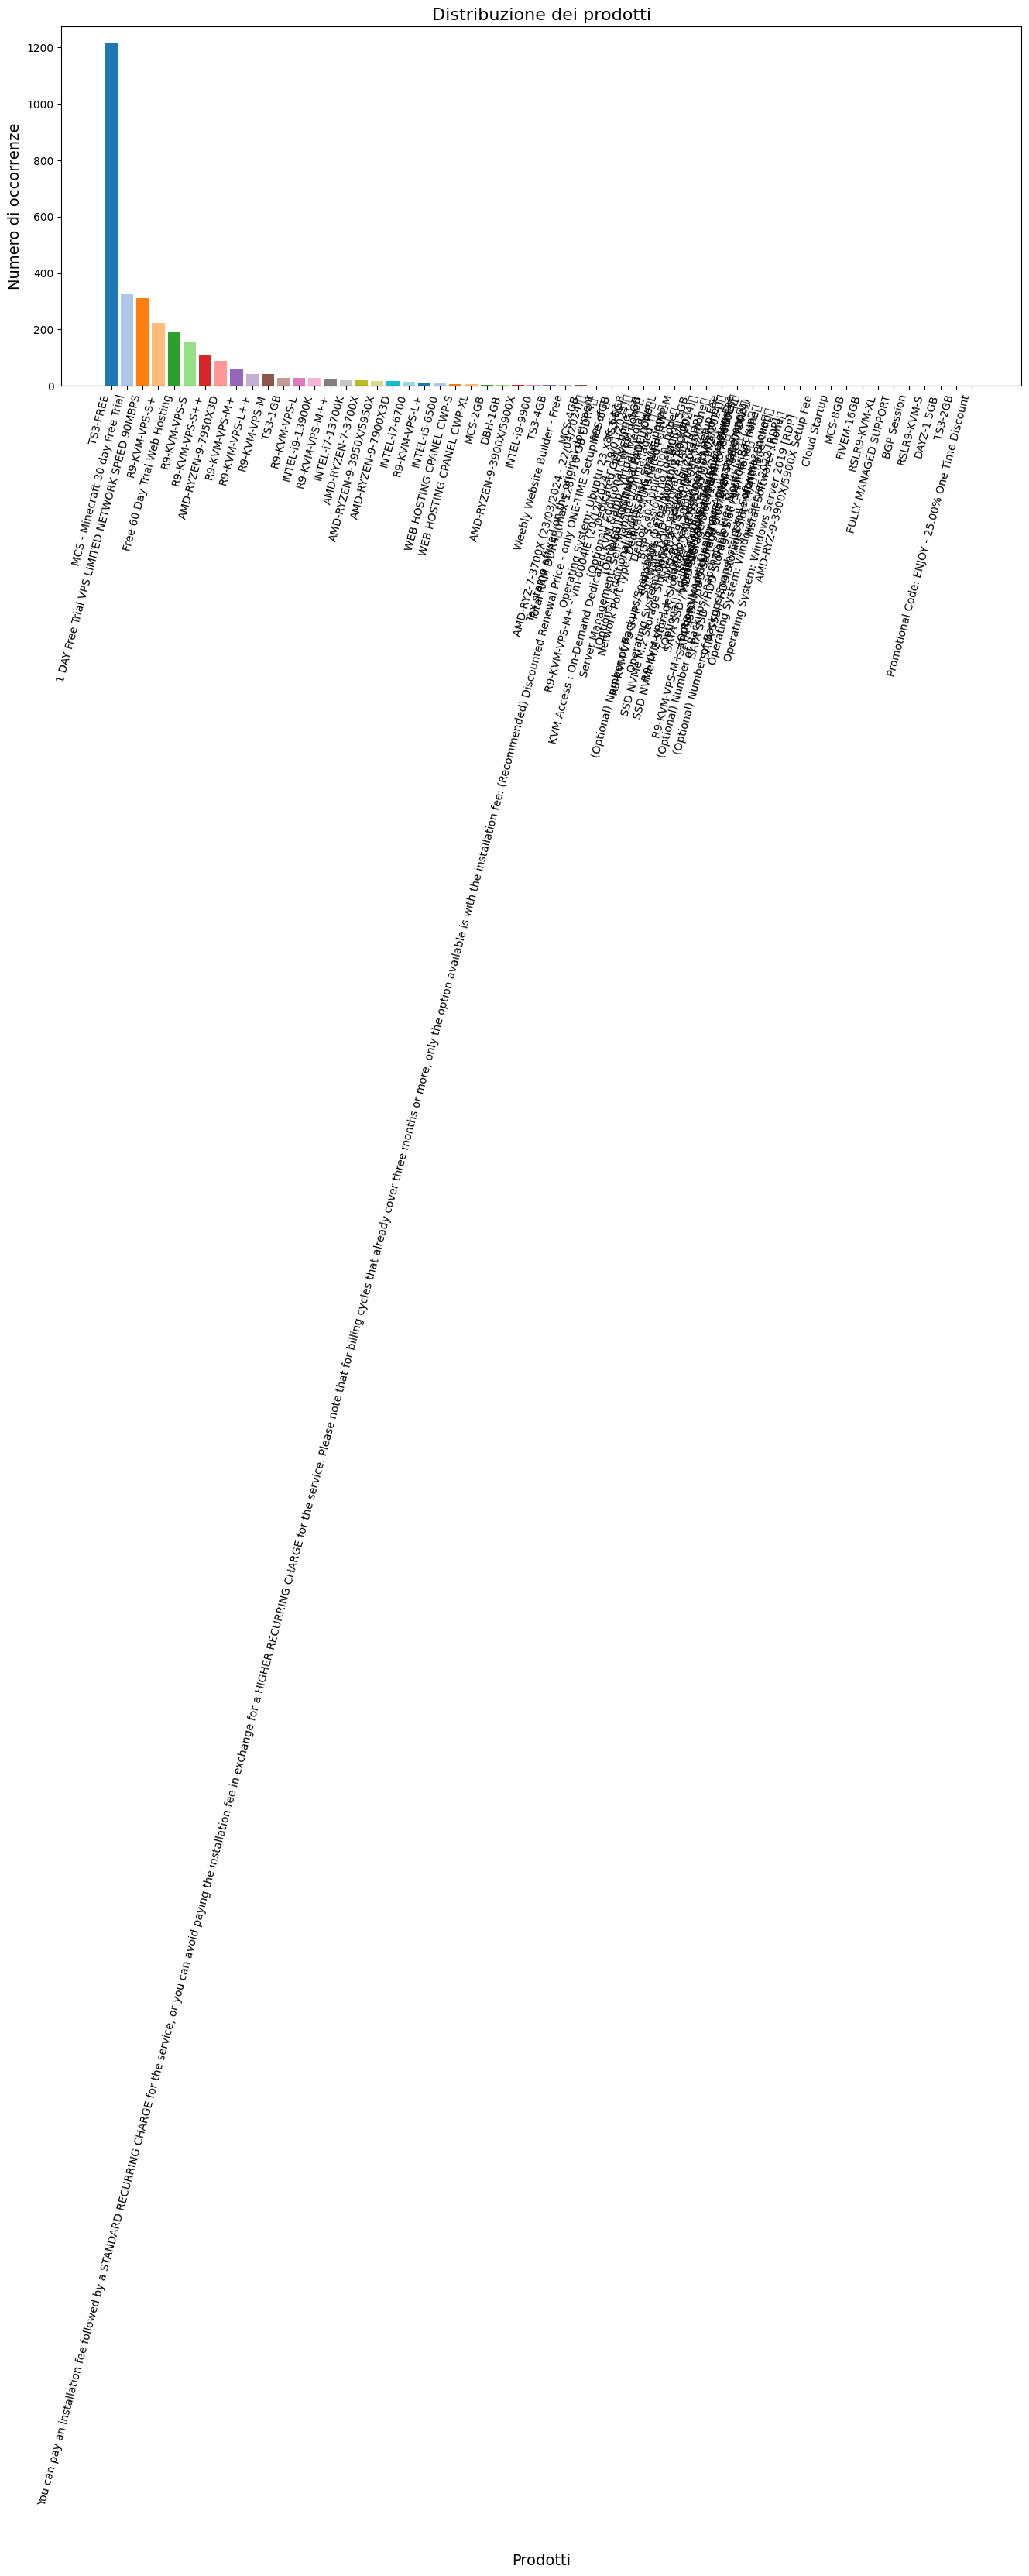

In [43]:
# Raggruppa i dati in base ai prodotti e conta le occorrenze
product_counts = df['product'].value_counts()

# Creazione del grafico a barre con dimensioni maggiori
plt.figure(figsize=(16, 8))  # Aumentata la dimensione del grafico

# Creazione del grafico a barre
bars = plt.bar(product_counts.index, product_counts, color=cm.tab20.colors[:len(product_counts)])

# Aggiunta delle etichette e del titolo
plt.xlabel("Prodotti", fontsize=14)
plt.ylabel("Numero di occorrenze", fontsize=14)
plt.title("Distribuzione dei prodotti", fontsize=16)

# Ruota le etichette sull'asse X e aumenta la dimensione del font
plt.xticks(rotation=75, ha="right", fontsize=10)

# Aggiunge spazio ai lati per evitare sovrapposizioni
plt.subplots_adjust(bottom=0.3)

# Mostra il grafico
plt.show()

# 3. Analisi esplorativa del dataset

In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3109 entries, 0 to 4624
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fraud          3109 non-null   int64  
 1   amount         3109 non-null   float64
 2   paymentmethod  3109 non-null   object 
 3   status         3109 non-null   object 
 4   risk_score     3109 non-null   float64
 5   product        3049 non-null   object 
dtypes: float64(2), int64(1), object(3)
memory usage: 170.0+ KB


## 3.1 Analisi bivariata

+ Prima di procedere all'analisi bivariata è necessario andare a categorizzare la variabili che lo richiedono

+ Le variabili categoriche che necessitano essere trasformate in variabili numeriche sono: `paymentmethod`,`status`,`fraudmodule` e `product`

In [45]:
def label_encode_categorical(df_new, column_name):
    """
    Applica il label encoding a una variabile categoriale e restituisce
    il dataframe trasformato e un dizionario con i valori mappati.

    Args:
        df_new (pd.DataFrame): Il dataframe di input.
        column_name (str): Il nome della colonna categoriale da trasformare.

    Returns:
        pd.DataFrame: Il dataframe con la colonna codificata.
        dict: Dizionario con i valori originali e i corrispondenti codici numerici.
    """
    # Ottieni i valori univoci della colonna e assegna un numero intero a ciascuno
    unique_values = df_new[column_name].unique()
    mapping_dict = {value: idx for idx, value in enumerate(unique_values)}
    
    # Sostituisci i valori della colonna con i numeri corrispondenti
    df_new[column_name] = df_new[column_name].map(mapping_dict)
    
    return df_new, mapping_dict


+ Label enconding di `paymentmethod`

In [46]:
df,dict_paymentmehtod=label_encode_categorical(df,"paymentmethod")

In [47]:
dict_paymentmehtod

{'stripe': 0, 'banktransfer': 1, 'coingate': 2, 'free': 3, 'paypalcheckout': 4}

+ Label enconding di `product_name`

In [48]:
df,dict_productname=label_encode_categorical(df,"product")

In [49]:
dict_productname

{'1 DAY Free Trial VPS LIMITED NETWORK SPEED 90MBPS': 0,
 'R9-KVM-VPS-S+': 1,
 'R9-KVM-VPS-S': 2,
 'MCS - Minecraft 30 day Free Trial': 3,
 nan: 4,
 'MCS-4GB': 5,
 'R9-KVM-VPS-M+': 6,
 'AMD-RYZEN-9-7950X3D': 7,
 'TS3-FREE': 8,
 'R9-KVM-VPS-S++': 9,
 'AMD-RYZEN-9-7900X3D': 10,
 'R9-KVM-VPS-L+': 11,
 'Free 60 Day Trial Web Hosting': 12,
 'Weebly Website Builder - Free': 13,
 'INTEL-i9-13900K': 14,
 'R9-KVM-VPS-L++': 15,
 'INTEL-i7-6700': 16,
 'R9-KVM-VPS-M': 17,
 'TS3-1GB': 18,
 'R9-KVM-VPS-L': 19,
 'INTEL-i7-13700K': 20,
 'WEB HOSTING CPANEL CWP-S': 21,
 'AMD-RYZEN-7-3700X': 22,
 'AMD-RYZEN-9-3950X/5950X': 23,
 'AMD-RYZEN-9-3900X/5900X': 24,
 'DBH-1GB': 25,
 'MCS-1.5GB': 26,
 'WEB HOSTING CPANEL CWP-XL': 27,
 'R9-KVM-VPS-M++': 28,
 'INTEL-i5-6500': 29,
 'TS3-2GB': 30,
 'WEB HOSTING CPANEL CWP-M': 31,
 'WEB HOSTING CPANEL CWP-L': 32,
 'DAYZ-1.5GB': 33,
 'FIVEM-1.5GB': 34,
 'RSLR9-KVM-S': 35,
 'MCS-2GB': 36,
 'INTEL-i9-9900': 37,
 'BGP Session': 38,
 'MCS-6GB': 39,
 'Cloud Startup': 40,
 

+ Label enconding di `status`

In [50]:
df,dict_status=label_encode_categorical(df,"status")

In [51]:
dict_status

{'Pending': 0, 'Cancelled': 1, 'Fraud': 2, 'Active': 3}

## 3.1.1 Ricerca correlazione tra le variabili numeriche e la variabile binaria `Status`

#### Test di Kruskal-Wallis
+ Il test di Kruskal-Wallis è progettato per confrontare la distribuzione di una variabile numerica tra due o più gruppi distinti, basandosi sui ranghi dei valori. Se la variabile binaria (ad esempio, con valori 0 e 1) viene usata per dividere i dati in due gruppi, il test permette di verificare se i valori della variabile numerica differiscono significativamente tra questi due gruppi.

In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3109 entries, 0 to 4624
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Fraud          3109 non-null   int64  
 1   amount         3109 non-null   float64
 2   paymentmethod  3109 non-null   int64  
 3   status         3109 non-null   int64  
 4   risk_score     3109 non-null   float64
 5   product        3109 non-null   int64  
dtypes: float64(2), int64(4)
memory usage: 170.0 KB


In [53]:
from scipy.stats import kruskal

#This function is for applying the test of Kruskal-Wallis and to compute the value of the epsilon squared
def calculate_epsilon_squared_for_columns(data, cols_of_interest, response_col):
    epsilon_squared_results = {}
    def calculate_epsilon_squared(H, k, n):
        epsilon_squared = (H - k + 1) / (n - k)
        return epsilon_squared
    for col in cols_of_interest:
        groups = [group[col].values for name, group in data.groupby(response_col)]
        H, p_value = kruskal(*groups)
        k = len(groups)
        n = len(data)
        epsilon_squared = calculate_epsilon_squared(H, k, n)
        epsilon_squared_results[col] = {'H': H, 'p-value': p_value, 'epsilon_squared': epsilon_squared}
    for key, value in epsilon_squared_results.items():
        print(f"Variabile: {key}")
        print(f"H: {value['H']:.4f}, p-value: {value['p-value']:.4f}, Epsilon Squared: {value['epsilon_squared']:.4f}")
        print("-------------------")


In [54]:
colonne_numeriche = ["risk_score", "amount"]
response_col = "Fraud"
calculate_epsilon_squared_for_columns(df, colonne_numeriche, response_col)



Variabile: risk_score
H: 15.6824, p-value: 0.0001, Epsilon Squared: 0.0047
-------------------
Variabile: amount
H: 132.8025, p-value: 0.0000, Epsilon Squared: 0.0424
-------------------


### "risk_score" VS "Fraud"
+ Un valore di 0.0047 indica che solo lo 0.47% della varianza totale di risk_score è attribuibile alla variabile di risposta Fraud.
+ Sebbene il risultato sia statisticamente significativo, l'effetto è molto piccolo, suggerendo una debole relazione.

### "amount" VS "Fraud"
+ Indica che il 4.24% della varianza totale di amount è spiegata dalla variabile di risposta Fraud.
+ Anche qui, sebbene l'effetto sia statisticamente significativo, è molto piccolo.

## 3.1.2 Ricerca di correlazione tra le variabili cateogriche e la variabile binaria `Status`

+ Per fare ciò andremo ad utilizzare il Chi-Square test

Il Chi-Square Test può essere utilizzato per analizzare la correlazione tra una variabile categorica e una variabile binaria perché è progettato per verificare se esiste un'associazione significativa tra due variabili categoriche

In [55]:
from scipy.stats import chi2_contingency 

#This function is for applying the chi Square test between the variables in the lists taken as input and the "TARGET" variable
def chi_square(data_copy, cols_of_interest):
    dati_selected = data_copy[cols_of_interest]
    chi2_results = {}
    for col in cols_of_interest:
        if col != 'Fraud':
            contingency_table = pd.crosstab(dati_selected[col], dati_selected['status'])
            chi2, p, dof, ex = chi2_contingency(contingency_table)
            chi2_results[col] = {'chi2': chi2, 'p-value': p, 'degrees_of_freedom': dof}
    for key, value in chi2_results.items():
        print(f"Variabile: {key}")
        print(f"Chi2: {value['chi2']:.4f}, p-value: {value['p-value']}, gradi di libertà: {value['degrees_of_freedom']}")
        print("--------------------")

In [56]:
colonne_categoriche = ["paymentmethod","status","product"]

In [57]:
chi_square(df,colonne_categoriche)

Variabile: paymentmethod
Chi2: 1277.4728, p-value: 3.5574082300114624e-266, gradi di libertà: 12
--------------------
Variabile: status
Chi2: 9327.0000, p-value: 0.0, gradi di libertà: 9
--------------------
Variabile: product
Chi2: 2403.1574, p-value: 0.0, gradi di libertà: 168
--------------------


### chi_square(df, colonne_categoriche)

+ status: Chi2: 9327  Un valore estremamente basso del p-value indica che c'è un'associazione statisticamente significativa tra status e Fraud.
+ product: Chi2:2403  Un valore estremamente basso del p-value indica che c'è un'associazione statisticamente significativa tra product e Fraud.
+ paymentmethod: Chi2=1277.5 Un valore estremamente basso del p-value indica che c'è un'associazione statisticamente significativa tra paymentmethod e Fraud.

+ Molto importante da tenere a mente che più alto è il valore del Chi2 più forte è la correlazione con la variabile target

## 3.2 Analisi multivariata

#### Al fine di andare a creare le mappe di calore è necessario andare a rimuovere le righe con i valori mancanti dal dataset


In [58]:
# Conta il numero di valori mancanti per ogni riga
missing_values_per_row = df.isnull().sum(axis=1)

# Conta quante righe hanno ciascun numero di valori mancanti
missing_count_dict = dict(sorted(missing_values_per_row.value_counts().to_dict().items(), reverse=True))

print("Dizionario dei valori mancanti:")
print(missing_count_dict)
# In this dictionary the key represents the number of missing values and the value associated to the key represents 
# the number of rows that have this number of missing values


Dizionario dei valori mancanti:
{0: 3109}


In [59]:
df

,Fraud,amount,paymentmethod,status,risk_score,product
0,0,0.00,0,0,86.40,0
1,0,3.74,1,1,0.22,1
2,0,0.00,0,2,99.00,0
4,0,0.00,0,2,97.63,0
5,0,3.74,0,3,69.71,1
...,...,...,...,...,...,...
4620,1,115.12,0,3,1.68,53
4621,1,156.25,0,3,0.75,54
4622,1,252.87,0,3,0.10,51
4623,1,45.00,0,3,0.00,55


### Mappa di calore di Cramer

+ La mappa di calore di Cramér's V può essere utilizzata solo per variabili categoriche perché Cramér's V è una misura di associazione tra due variabili categoriche basata sulla tabella di contingenza e sulla statistica Chi-quadro (χ²).

In [60]:
colonne_categoriche = ["paymentmethod","status","product","Fraud"]

In [61]:
#This function is for plotting the Cramers' Heatmap
def cramers_v_heatmap(data, cols_of_interest):
    def cramers_v(x, y):
        confusion_matrix = pd.crosstab(x, y)
        chi2 = chi2_contingency(confusion_matrix)[0]
        n = confusion_matrix.sum().sum()
        phi2 = chi2 / n
        r, k = confusion_matrix.shape
        phi2corr = max(0, phi2 - ((k - 1) * (r - 1)) / (n - 1))
        rcorr = r - ((r - 1) ** 2) / (n - 1)
        kcorr = k - ((k - 1) ** 2) / (n - 1)
        return np.sqrt(phi2corr / min((kcorr - 1), (rcorr - 1)))
    dati_selected = data[cols_of_interest]
    n = len(cols_of_interest)
    cramers_v_matrix = np.zeros((n, n))
    for i in range(n):
        for j in range(i, n):  # Calcoliamo solo la metà superiore della matrice per ottimizzare
            cramers_v_matrix[i, j] = cramers_v(dati_selected.iloc[:, i], dati_selected.iloc[:, j])
            cramers_v_matrix[j, i] = cramers_v_matrix[i, j]  # La matrice è simmetrica
    
    cramers_v_df = pd.DataFrame(cramers_v_matrix, index=cols_of_interest, columns=cols_of_interest)
    mask = np.zeros_like(cramers_v_df)
    mask[np.triu_indices_from(mask)] = True
    plt.figure(figsize=(12, 10))
    sns.heatmap(cramers_v_df, annot=True, mask=mask, vmin=0, vmax=1, center=0.5, square=True, cmap="YlGnBu", fmt=".2f")
    plt.show()

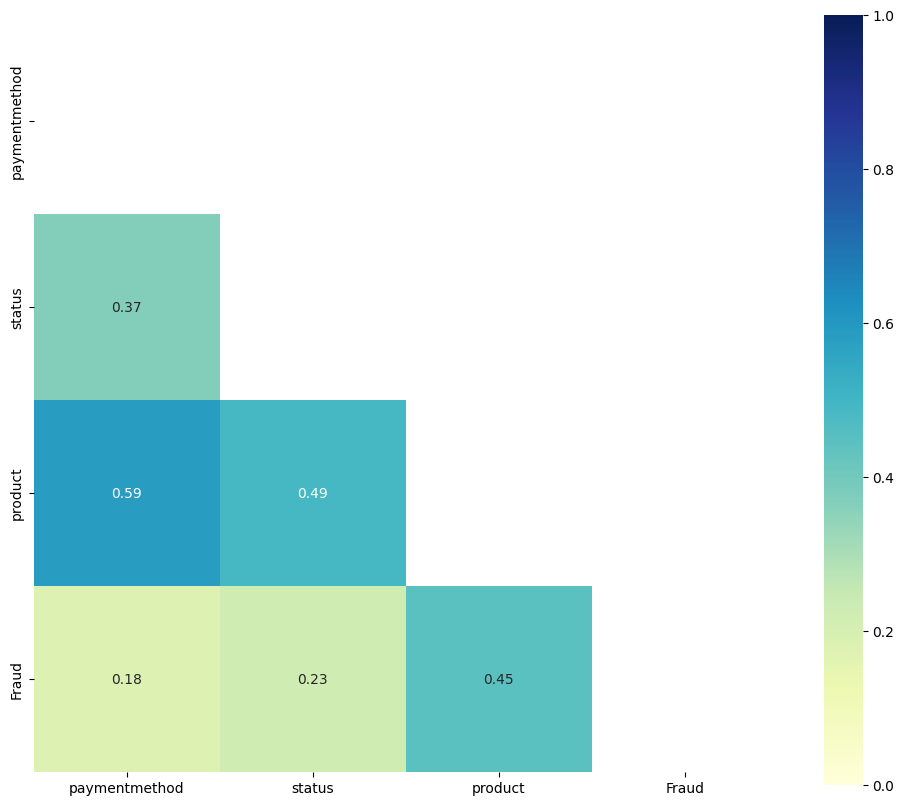

In [62]:
cramers_v_heatmap(df, colonne_categoriche)

## Mappa di calore di Pearson

+ Il coefficiente di Pearson misura la correlazione lineare tra due variabili.
+ È appropriato per variabili numeriche continue, in cui il concetto di distanza o scala numerica è ben definito.
+ Tuttavia, variabili categoriche possono essere incluse se sono codificate numericamente, trasformandole in una forma compatibile.

<Axes: >

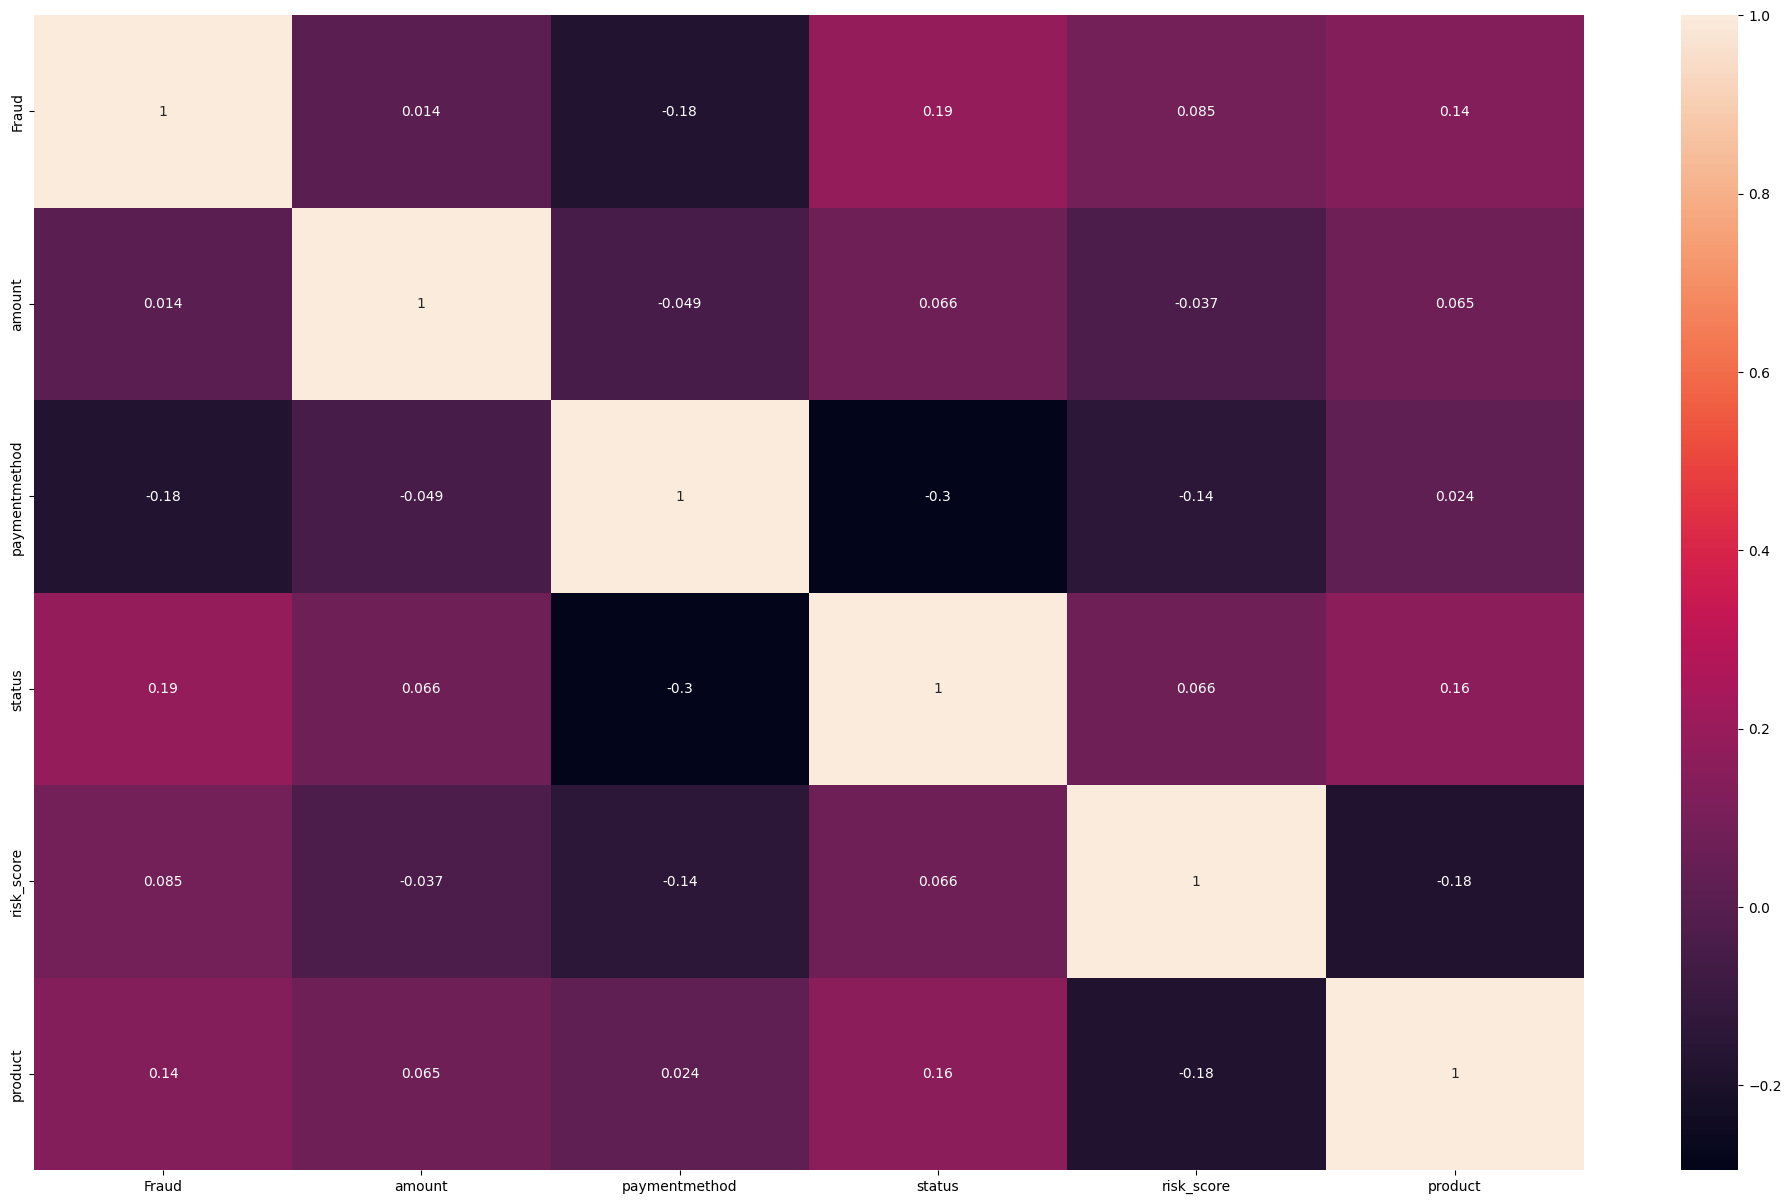

In [63]:
import seaborn as sns
# correlation matrix
plt.figure(figsize=(25,15))
sns.heatmap(df.corr(),annot=True)

# Mappa di calore di Spearman

+ La mappa di calore di Spearman (basata sul coefficiente di correlazione di Spearman) può essere utilizzata sia per variabili numeriche che per variabili categoriche, grazie alle caratteristiche non parametriche del coefficiente di Spearman, che si basa sui ranghi dei dati.

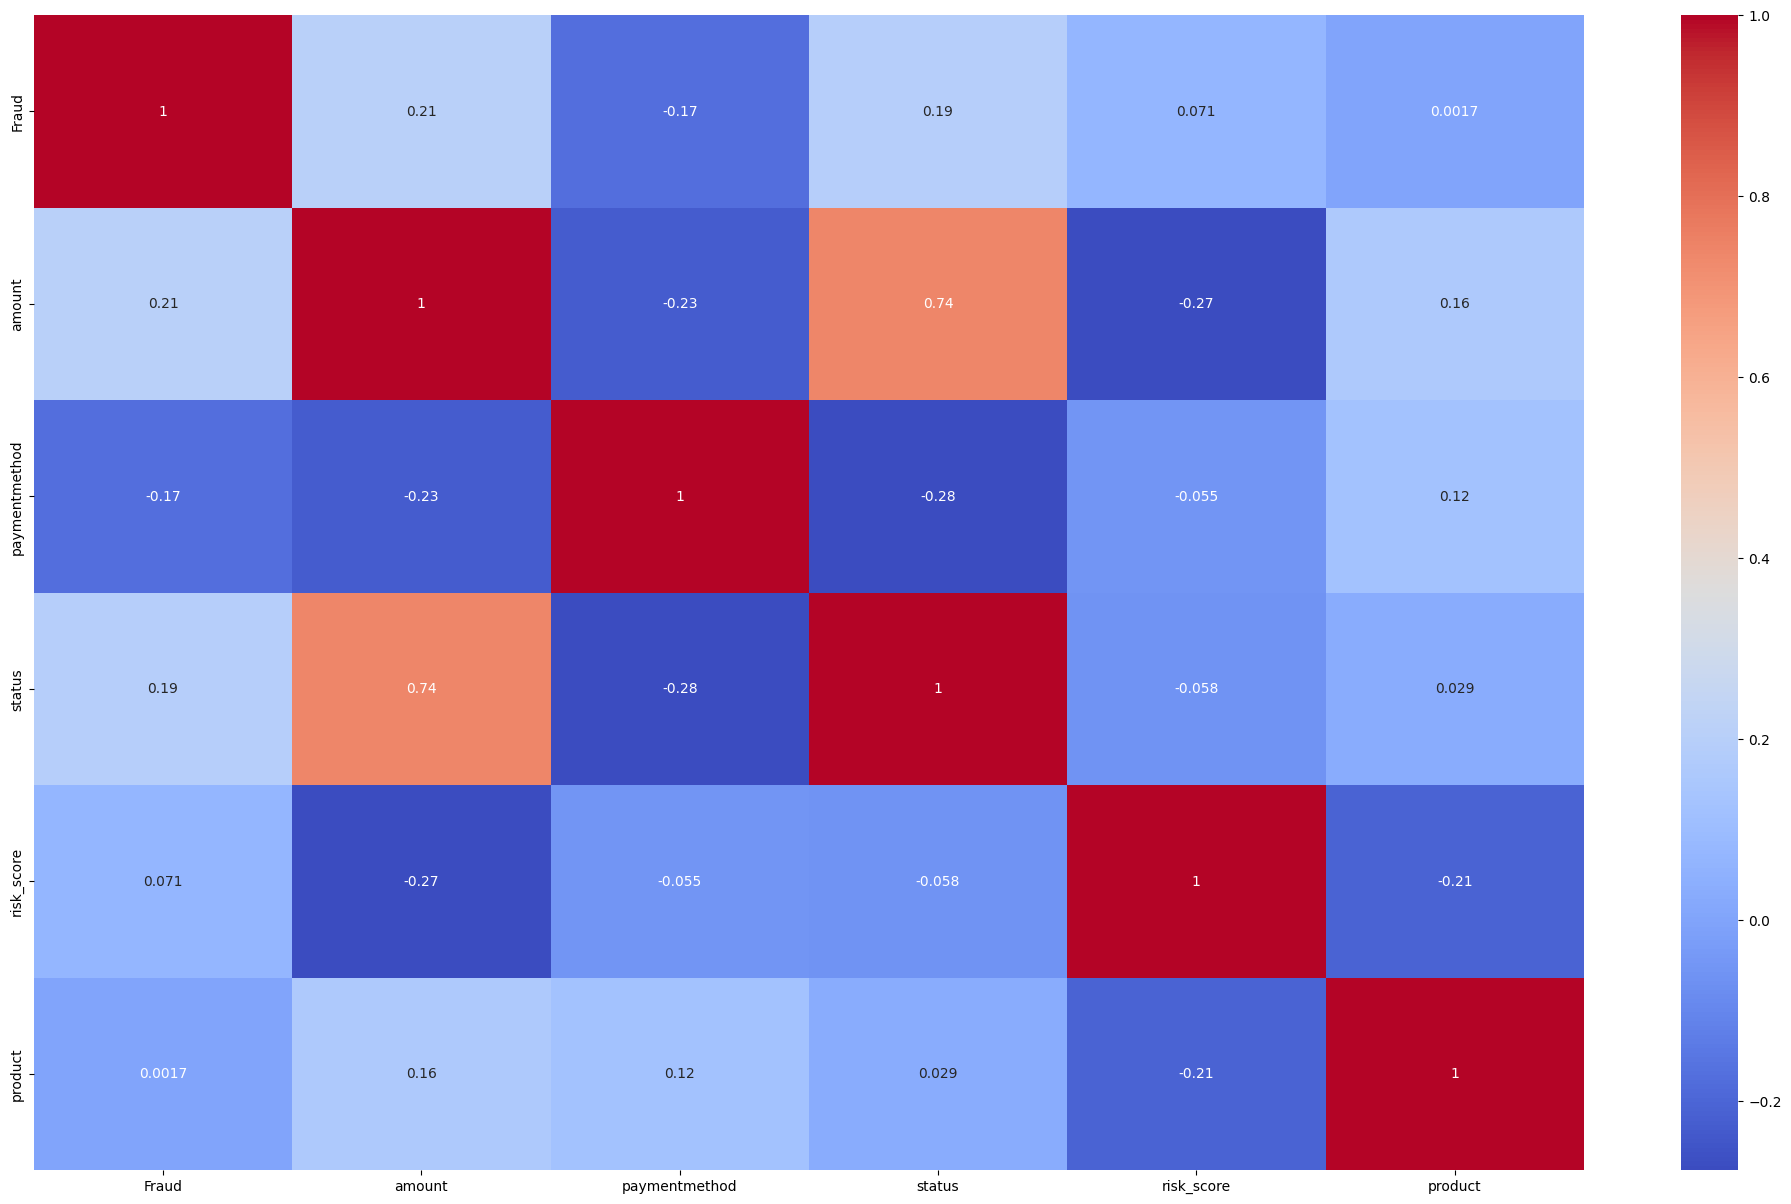

In [64]:
plt.figure(figsize=(25, 15))
sns.heatmap(df.corr(method='spearman'), annot=True, cmap='coolwarm')
plt.show()

In [65]:
df.head()

,Fraud,amount,paymentmethod,status,risk_score,product
0,0,0.00,0,0,86.40,0
1,0,3.74,1,1,0.22,1
2,0,0.00,0,2,99.00,0
4,0,0.00,0,2,97.63,0
5,0,3.74,0,3,69.71,1


In [66]:
#This function is for applying the Spearman test
def spearman_significance(var1, var2,data_copy):
    spearman_corr, p_value = spearmanr(data_copy[var1], data_copy[var2])
    print(f"Spearman's Coefficiente between '{var1}' and '{var2}': {spearman_corr:.3f}")
    print(f"p-value: {p_value:.4f}")
    if p_value < 0.05:
        print(f"Exists a significant correlation between '{var1}' and '{var2}'.")
    else:
        print(f"Doesn't exist a significant correlation between '{var1}' and '{var2}'.")     
    return spearman_corr, p_value

### IN PRIMO LUOGO VADO A VEDERE SE LE VARIABILI NON CATEGORICHE(in quanto si è già visto che lo sono) CHE RISULTANO AVERE UNA BASSA CORRELAZIONE CON LA VARIABILE TARGET RISULTANO ESSERE SIGNIFICATIVAMENTE CORRELATE CON LA VARIABILE TARGET

+ `Fraud` (binaria) vs `amount` (numerica) 

In [67]:
spearman_significance("Fraud","amount",df)

Spearman's Coefficiente between 'Fraud' and 'amount': 0.207
p-value: 0.0000
Exists a significant correlation between 'Fraud' and 'amount'.


(0.20671054655622917, 2.370508064636789e-31)

+ `risk_score` (numerica) vs `Fraud` (binaria)

In [68]:
spearman_significance("risk_score","Fraud",df)

Spearman's Coefficiente between 'risk_score' and 'Fraud': 0.071
p-value: 0.0001
Exists a significant correlation between 'risk_score' and 'Fraud'.


(0.07103395563863792, 7.365619436142439e-05)

### AL FINE DI PREVENIRE IL PROBLEMA DELLA MULTICOLLINEARITA' VADO A INDAGARE SE VI E' UNA CORRELAZIONE SIGINIFICATIVA TRA LE VARIABILI CHE HANNO MOSTRATO UN ALTO COEFFICIENTE DI CORRELAZIONE:

In [69]:
spearman_significance("status","amount",df)

Spearman's Coefficiente between 'status' and 'amount': 0.737
p-value: 0.0000
Exists a significant correlation between 'status' and 'amount'.


(0.7366861366543667, 0.0)

+ Dopo aver appurato che vi è una correlazione statisticamente significativa tra "status" e "amount" ho deciso di rimuovere la variabile "status" in quanto di minore rilevanza per l'analisi in questione e in uanto entrambe le variabili hanno mostrato uno stesso valore di associazione con la variabile target

In [70]:
df = df.drop(columns=['status'])

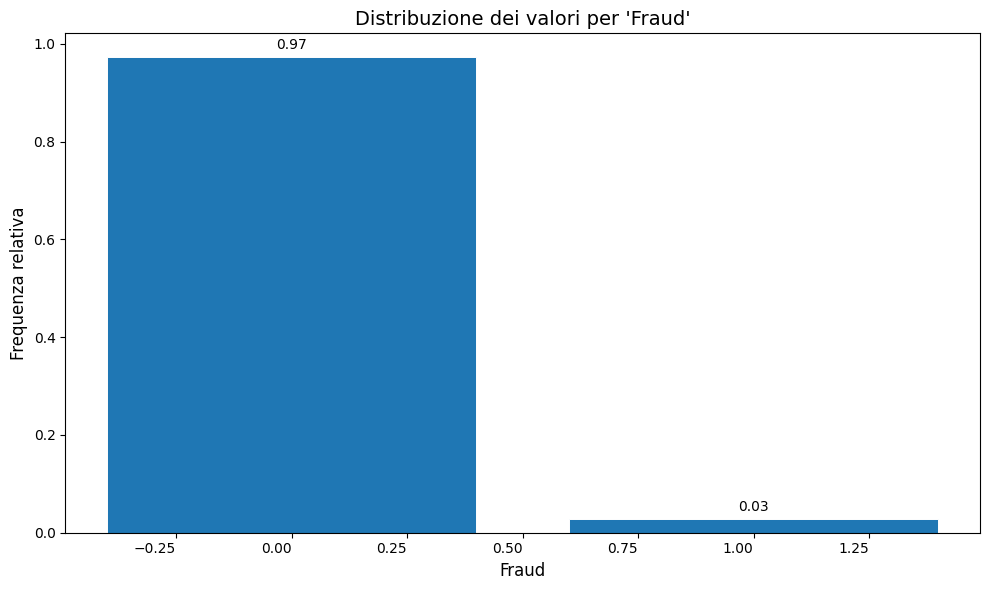

In [71]:
grafico_barre(df,'Fraud')

In [72]:
df["Fraud"].unique()

array([0, 1], dtype=int64)

### Undersampling per andare a rimuovere  il 90% delle transazioni non fraudolente, mentre per quanto riguarda le transazioni fraudolente visto che il numero di essere è altamente inferiore rispetto a qualle non fraudolente ho deciso di triplicare il loro numero andando a inserire ogni transazione di esse 3 volte all'interno del dataset, per fare ciò l'aumento delle trnasazioni fraudolenti verrà fatto DIRETTAMENTE E SOLAMENTE sul train set in maniera indipendente dal test per evitare il data leakage e per lasciare intatta la natura dei dati nel test set.

In [73]:
# Filtra le righe con Fraud = 0 e Fraud != 0
fraud_zero = df[df['Fraud'] == 0]
fraud_one = df[df['Fraud'] == 1]
# Sottocampiona le righe con Fraud = 0, mantenendo solo il 10%
fraud_zero_sampled = fraud_zero.sample(frac=0.7, random_state=42)
# Ricombina le righe sottocampionate con quelle non sottoposte a sottocampionamento
df_underfit = pd.concat([fraud_zero_sampled, fraud_one], ignore_index=True)

# Mostra il numero di righe dopo l'operazione
print(f"Numero di righe dopo undersampling: {df_underfit.shape[0]}")
#df = df_underfit

Numero di righe dopo undersampling: 2202


### NUOVA DISTRIBUZIONE DELLA VARIABILE "Fraud":

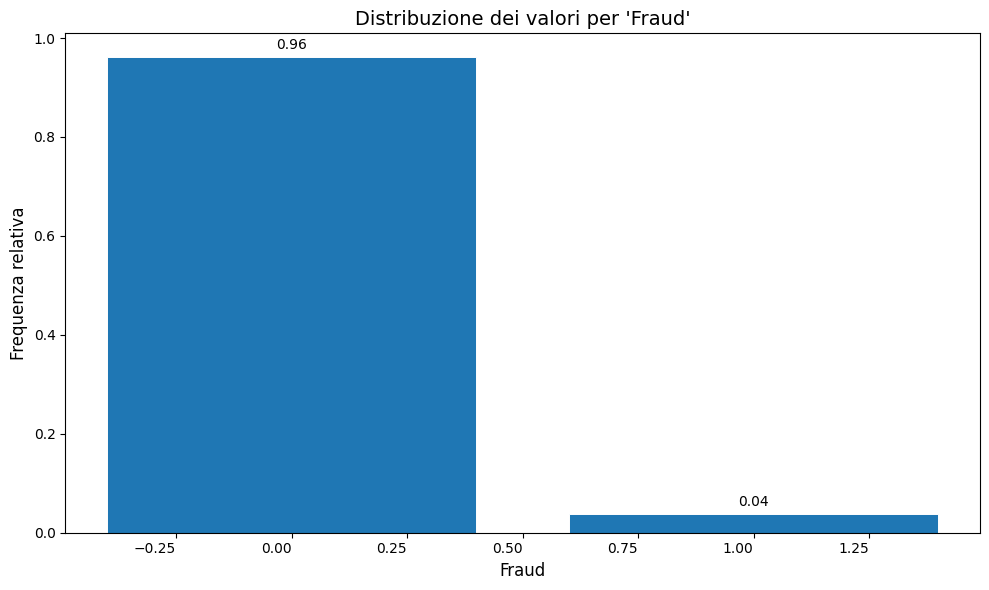

In [74]:
grafico_barre(df_underfit,'Fraud')

# 4. Individuazione dell'algoritmo ideale di ML

+ Viste le ridotte dimensioni del dataset abbiamo deciso di evitare l'utilizzo di algoritmi troppo complessi di Machine Learning per tanto ci siamo focalizzati solo sulla Regressione Logica e sul Decision Tree, inoltre vengono utilizzate 2  loss function customizzate usando una log-loss in cui la classe minoritaria (presumibilmente la frode, Fraud=1) riceve un peso maggiore (1.5) rispetto alla classe dominante (Fraud=0, che ha peso 1) e una Gini impurity( con class_weight={0: 1, 1: 1.5}), assegnando maggiore peso alla classe fraudolenta.

In [75]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score,precision_score,f1_score,accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import GridSearchCV

In [76]:
# Funzione per stampare il report di classificazione con soglia personalizzata
def print_classification_reports(model_name, model, threshold=0.5):
    print(model_name)
    print("TRAIN SET ---------------------------------")
    y_probs = model.predict_proba(X_train_resampled)[:, 1]  # Probabilità per la classe positiva
    y_pred_custom = (y_probs >= threshold).astype(int)  # Classificazione con soglia custom
    print(classification_report(y_train_resampled, y_pred_custom))
    print("TEST SET ---------------------------------")
    y_probs = model.predict_proba(X_test)[:, 1]  # Probabilità per la classe positiva
    y_pred_custom = (y_probs >= threshold).astype(int)  # Classificazione con soglia custom
    print(classification_report(y_test, y_pred_custom))

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
def plot_ROC(model_name,model):
    print(model_name)
    # Calculate ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:, 1])
    # Calculate AUC
    roc_auc = auc(fpr, tpr)
    # Plot ROC curve
    plt.figure()
    plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc="lower right")
    plt.show()

# LOGISTIC REGRESSION


--- Random State: 1 ---
Accuracy (RS=1): 0.6923
Logistic Regression - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.48      3763
   macro avg       0.53      0.52      0.45      3763
weighted avg       0.54      0.48      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.33      0.15      0.21        26
           1       0.45      0.69      0.55        26

    accuracy                           0.42        52
   macro avg       0.39      0.42      0.38        52
weighted avg       0.39      0.42      0.38        52

Logistic Regression - RS 1


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


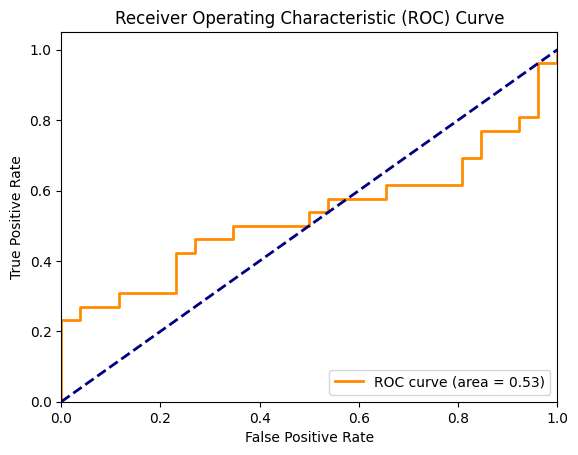


--- Random State: 2 ---
Accuracy (RS=2): 0.7308
Logistic Regression - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.48      3763
   macro avg       0.53      0.52      0.45      3763
weighted avg       0.54      0.48      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.33      0.08      0.12        26
           1       0.48      0.85      0.61        26

    accuracy                           0.46        52
   macro avg       0.41      0.46      0.37        52
weighted avg       0.41      0.46      0.37        52

Logistic Regression - RS 2


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


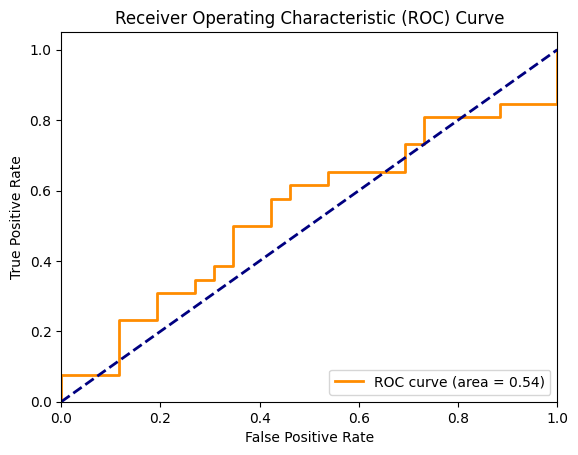


--- Random State: 3 ---
Accuracy (RS=3): 0.7692
Logistic Regression - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.48      3763
   macro avg       0.53      0.52      0.45      3763
weighted avg       0.54      0.48      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.60      0.23      0.33        26
           1       0.52      0.85      0.65        26

    accuracy                           0.54        52
   macro avg       0.56      0.54      0.49        52
weighted avg       0.56      0.54      0.49        52

Logistic Regression - RS 3


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


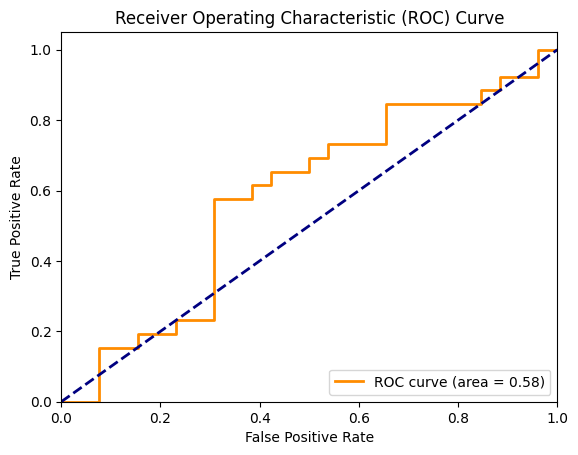


--- Random State: 4 ---
Accuracy (RS=4): 0.8269
Logistic Regression - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.48      3763
   macro avg       0.53      0.52      0.45      3763
weighted avg       0.54      0.48      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.58      0.27      0.37        26
           1       0.53      0.81      0.64        26

    accuracy                           0.54        52
   macro avg       0.55      0.54      0.50        52
weighted avg       0.55      0.54      0.50        52

Logistic Regression - RS 4


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


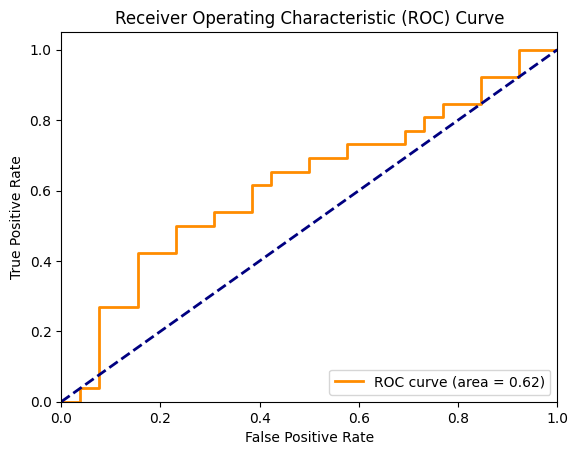


--- Random State: 5 ---
Accuracy (RS=5): 0.7885
Logistic Regression - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.48      3763
   macro avg       0.53      0.52      0.45      3763
weighted avg       0.54      0.48      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.40      0.08      0.13        26
           1       0.49      0.88      0.63        26

    accuracy                           0.48        52
   macro avg       0.44      0.48      0.38        52
weighted avg       0.44      0.48      0.38        52

Logistic Regression - RS 5


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


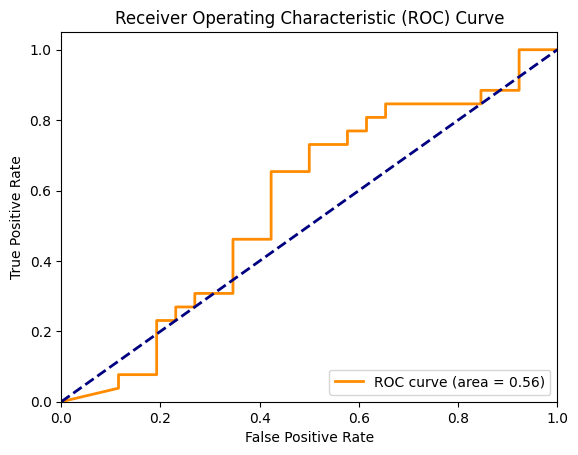


✅ Accuracy media sui 5 split: 0.7615


In [78]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che df_underfit abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione casuale di 26 osservazioni per ciascuna classe per il test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    # Creazione del test set
    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Creazione del training set (il resto dei dati)
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # Applica SMOTE
    smote = SMOTE(sampling_strategy=0.8, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Normalizzazione
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)

    # Regressione Logistica
    logreg = LogisticRegression(C=0.8, random_state=0, solver='lbfgs', class_weight={0: 1, 1: 2})
    logreg.fit(X_train_scaled, y_train_resampled)

    # Accuracy
    y_pred = logreg.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"Logistic Regression - RS {random_state}", logreg)
    plot_ROC(f"Logistic Regression - RS {random_state}", logreg)

# Accuracy media
mean_acc = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_acc:.4f}")


# DECISION TREE


--- Random State: 1 ---
Accuracy (RS=1): 0.8462
Decision Tree - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2091
           1       0.86      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.93      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        26
           1       0.88      0.81      0.84        26

    accuracy                           0.85        52
   macro avg       0.85      0.85      0.85        52
weighted avg       0.85      0.85      0.85        52

Decision Tree - RS 1


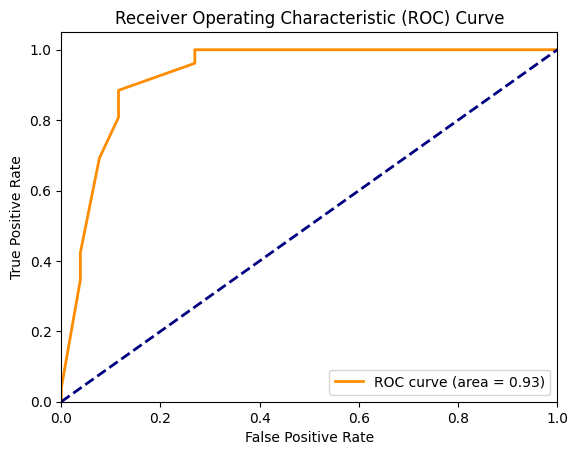


--- Random State: 2 ---
Accuracy (RS=2): 0.8846
Decision Tree - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2091
           1       0.86      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.93      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        26
           1       0.92      0.88      0.90        26

    accuracy                           0.90        52
   macro avg       0.90      0.90      0.90        52
weighted avg       0.90      0.90      0.90        52

Decision Tree - RS 2


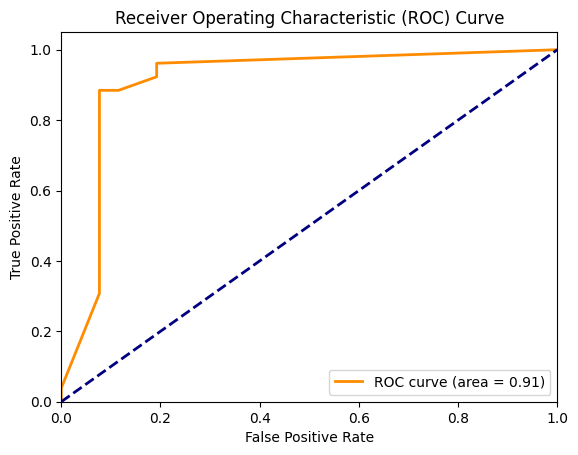


--- Random State: 3 ---
Accuracy (RS=3): 0.8462
Decision Tree - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2091
           1       0.86      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.93      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        26
           1       0.85      0.88      0.87        26

    accuracy                           0.87        52
   macro avg       0.87      0.87      0.87        52
weighted avg       0.87      0.87      0.87        52

Decision Tree - RS 3


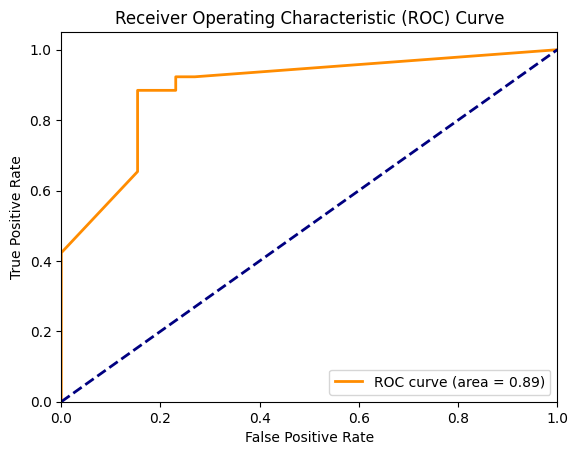


--- Random State: 4 ---
Accuracy (RS=4): 0.8654
Decision Tree - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2091
           1       0.86      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.93      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.95      0.81      0.88        26
           1       0.83      0.96      0.89        26

    accuracy                           0.88        52
   macro avg       0.89      0.88      0.88        52
weighted avg       0.89      0.88      0.88        52

Decision Tree - RS 4


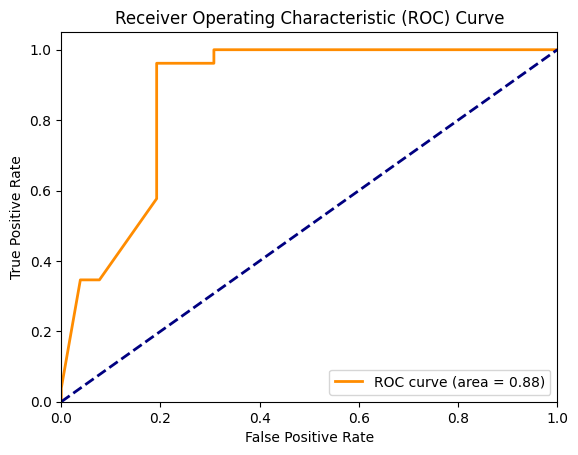


--- Random State: 5 ---
Accuracy (RS=5): 0.9231
Decision Tree - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.87      0.93      2091
           1       0.86      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.93      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.92      0.92      0.92        26

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52

Decision Tree - RS 5


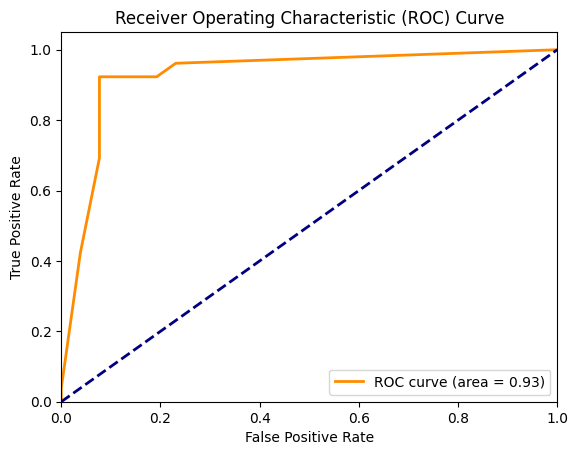


✅ Accuracy media sui 5 split: 0.8731


In [79]:
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che df_underfit abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []  # Per salvare le accuracy dei 5 split

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione delle classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione casuale di 26 osservazioni per ciascuna classe per il test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    # Creazione del test set
    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Rimozione osservazioni di test dal training set
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # Applica SMOTE solo al training set
    smote = SMOTE(sampling_strategy=0.8, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Addestramento albero decisionale
    dtree = DecisionTreeClassifier(
        max_depth=6,
        min_samples_split=8,
        random_state=42
    )
    dtree.fit(X_train_resampled, y_train_resampled)

    # Predizione e calcolo accuracy
    y_pred = dtree.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"Decision Tree - RS {random_state}", dtree)
    plot_ROC(f"Decision Tree - RS {random_state}", dtree)

# Accuracy media finale
mean_acc = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_acc:.4f}")


## RANDOM FOREST


--- Random State: 1 ---
Accuracy for RS 1: 0.8269
Random Forest - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2091
           1       0.87      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.94      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.79      0.88      0.84        26
           1       0.87      0.77      0.82        26

    accuracy                           0.83        52
   macro avg       0.83      0.83      0.83        52
weighted avg       0.83      0.83      0.83        52

Random Forest - RS 1


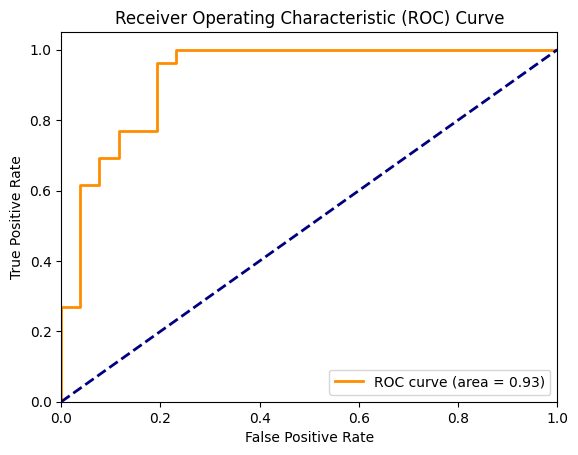


--- Random State: 2 ---
Accuracy for RS 2: 0.9038
Random Forest - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2091
           1       0.87      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.94      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        26
           1       0.92      0.88      0.90        26

    accuracy                           0.90        52
   macro avg       0.90      0.90      0.90        52
weighted avg       0.90      0.90      0.90        52

Random Forest - RS 2


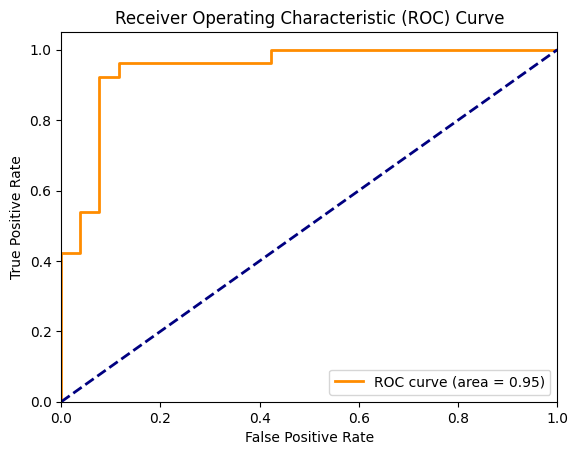


--- Random State: 3 ---
Accuracy for RS 3: 0.8654
Random Forest - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2091
           1       0.87      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.94      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.91      0.81      0.86        26
           1       0.83      0.92      0.87        26

    accuracy                           0.87        52
   macro avg       0.87      0.87      0.86        52
weighted avg       0.87      0.87      0.86        52

Random Forest - RS 3


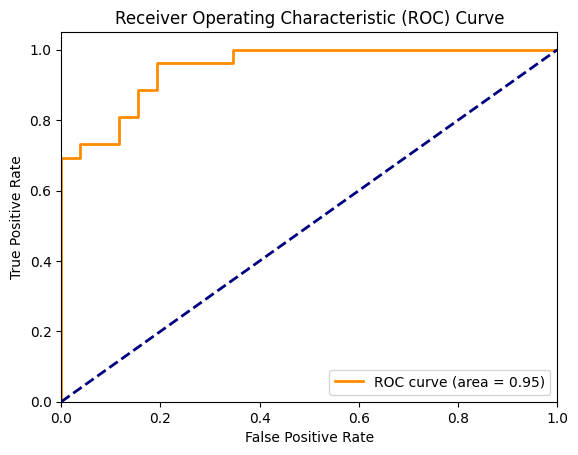


--- Random State: 4 ---
Accuracy for RS 4: 0.9423
Random Forest - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2091
           1       0.87      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.94      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.93      0.96      0.94        26

    accuracy                           0.94        52
   macro avg       0.94      0.94      0.94        52
weighted avg       0.94      0.94      0.94        52

Random Forest - RS 4


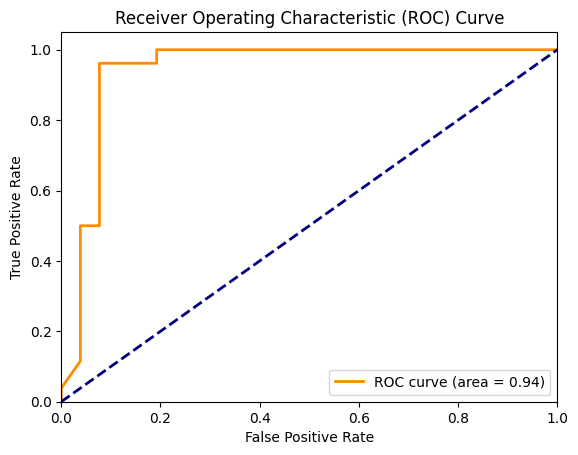


--- Random State: 5 ---
Accuracy for RS 5: 0.9231
Random Forest - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.99      0.88      0.93      2091
           1       0.87      0.99      0.92      1672

    accuracy                           0.93      3763
   macro avg       0.93      0.93      0.93      3763
weighted avg       0.94      0.93      0.93      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.92      0.92      0.92        26

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52

Random Forest - RS 5


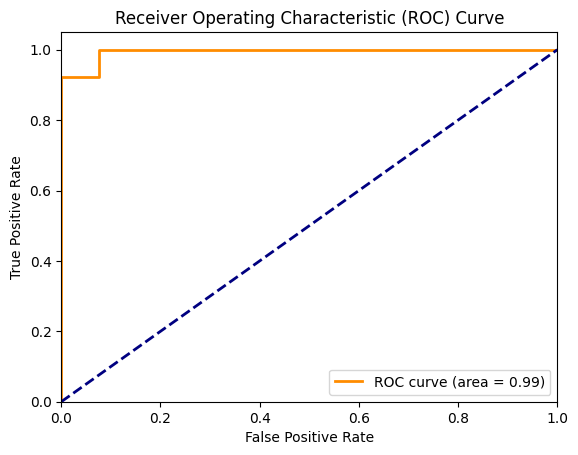


✅ Accuracy media sui 5 split: 0.8923


In [80]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import numpy as np
import pandas as pd

# Supponiamo che df_underfit abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []  # Lista per salvare le accuracy dei 5 split

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione delle classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione casuale di 26 osservazioni per ciascuna classe per il test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    # Creazione del test set
    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Rimozione osservazioni di test dal training set
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # SMOTE
    smote = SMOTE(sampling_strategy=0.8, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Classificatore Random Forest semplificato
    rf = RandomForestClassifier(
        n_estimators=30,
        max_depth=6,
        min_samples_split=10,
        random_state=42,
        class_weight={0: 1, 1: 1}
    )

    # Fit
    rf.fit(X_train_resampled, y_train_resampled)

    # Accuracy sul test set
    y_pred = rf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy for RS {random_state}: {acc:.4f}")
    print_classification_reports(f"Random Forest - RS {random_state}", rf)
    plot_ROC(f"Random Forest - RS {random_state}", rf)

# Calcolo e stampa dell'accuracy media
mean_acc = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_acc:.4f}")


## XGBOSST


--- Random State: 1 ---


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:08:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Accuracy (RS=1): 0.7692
XGBoost - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2091
           1       0.86      0.97      0.91      1672

    accuracy                           0.91      3763
   macro avg       0.91      0.92      0.91      3763
weighted avg       0.92      0.91      0.91      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.75      0.81      0.78        26
           1       0.79      0.73      0.76        26

    accuracy                           0.77        52
   macro avg       0.77      0.77      0.77        52
weighted avg       0.77      0.77      0.77        52

XGBoost - RS 1


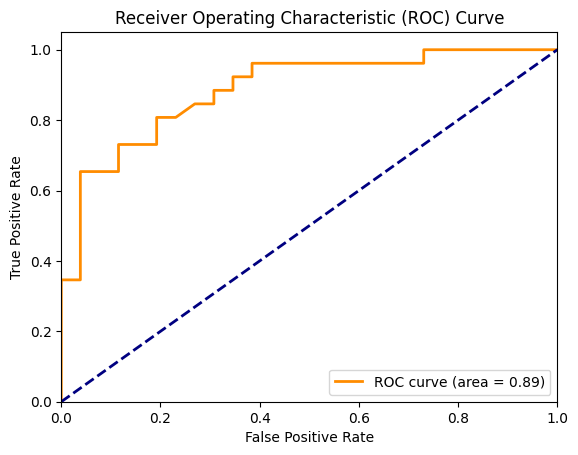


--- Random State: 2 ---
Accuracy (RS=2): 0.9038
XGBoost - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2091
           1       0.86      0.97      0.91      1672

    accuracy                           0.91      3763
   macro avg       0.91      0.92      0.91      3763
weighted avg       0.92      0.91      0.91      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        26
           1       0.92      0.88      0.90        26

    accuracy                           0.90        52
   macro avg       0.90      0.90      0.90        52
weighted avg       0.90      0.90      0.90        52

XGBoost - RS 2


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:08:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


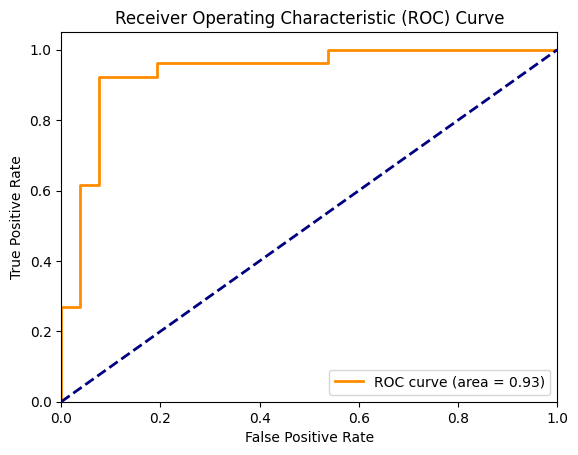


--- Random State: 3 ---
Accuracy (RS=3): 0.8654
XGBoost - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2091
           1       0.86      0.97      0.91      1672

    accuracy                           0.91      3763
   macro avg       0.91      0.92      0.91      3763
weighted avg       0.92      0.91      0.91      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.88      0.85      0.86        26
           1       0.85      0.88      0.87        26

    accuracy                           0.87        52
   macro avg       0.87      0.87      0.87        52
weighted avg       0.87      0.87      0.87        52

XGBoost - RS 3


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:08:39] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


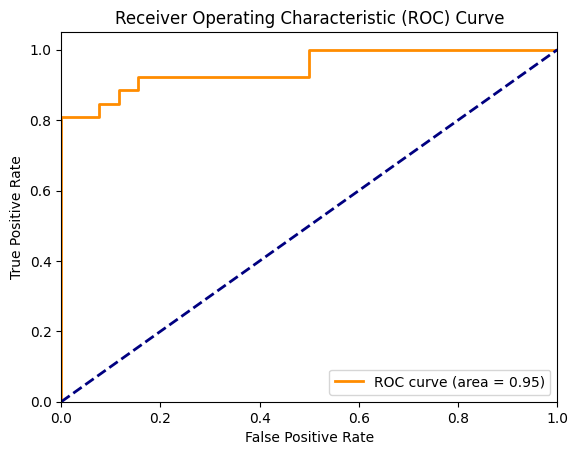


--- Random State: 4 ---
Accuracy (RS=4): 0.9231
XGBoost - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2091
           1       0.86      0.97      0.91      1672

    accuracy                           0.91      3763
   macro avg       0.91      0.92      0.91      3763
weighted avg       0.92      0.91      0.91      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.96      0.88      0.92        26
           1       0.89      0.96      0.93        26

    accuracy                           0.92        52
   macro avg       0.93      0.92      0.92        52
weighted avg       0.93      0.92      0.92        52

XGBoost - RS 4


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:08:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


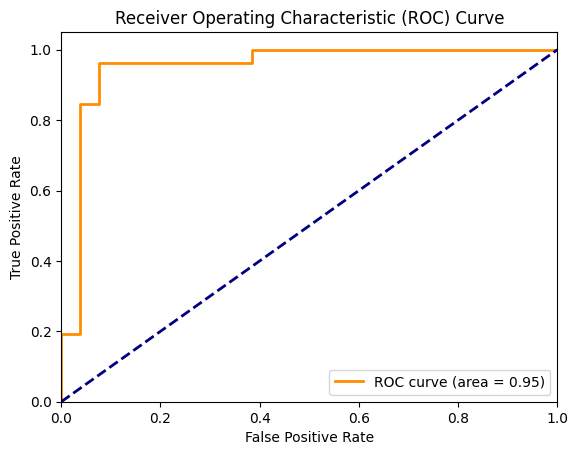


--- Random State: 5 ---
Accuracy (RS=5): 0.9615
XGBoost - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.97      0.87      0.92      2091
           1       0.86      0.97      0.91      1672

    accuracy                           0.91      3763
   macro avg       0.91      0.92      0.91      3763
weighted avg       0.92      0.91      0.91      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.93      1.00      0.96        26
           1       1.00      0.92      0.96        26

    accuracy                           0.96        52
   macro avg       0.96      0.96      0.96        52
weighted avg       0.96      0.96      0.96        52

XGBoost - RS 5


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [22:08:40] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


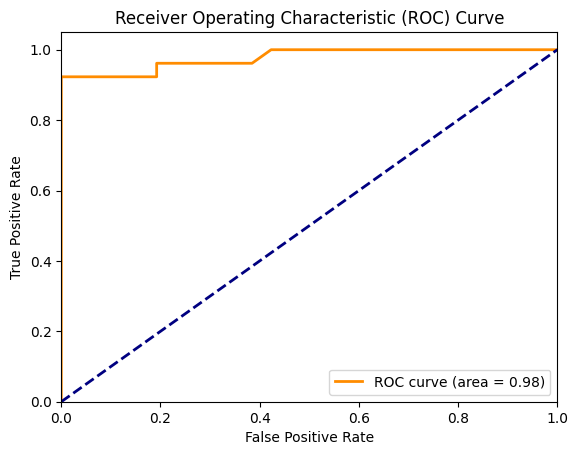


✅ Accuracy media sui 5 split: 0.8846
[0.7692307692307693, 0.9038461538461539, 0.8653846153846154, 0.9230769230769231, 0.9615384615384616]


In [81]:
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che df_underfit abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []  # Lista per salvare le accuracy

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione delle classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione casuale di 26 osservazioni per ciascuna classe per il test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Il resto è training set
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # Applica SMOTE
    smote = SMOTE(sampling_strategy=0.8, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

   # Classificatore XGBoost semplificato per ridurre l’overfitting
    xgb_model = XGBClassifier(
        n_estimators=30,
        max_depth=4,
        min_child_weight=3,
        subsample=0.7,
        colsample_bytree=0.7,
        learning_rate=0.1,
        use_label_encoder=False,
        eval_metric='logloss',
        random_state=42
    )

    # Addestramento
    xgb_model.fit(X_train_resampled, y_train_resampled)

    # Accuracy
    y_pred = xgb_model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"XGBoost - RS {random_state}", xgb_model)
    plot_ROC(f"XGBoost - RS {random_state}", xgb_model)

# Accuracy media
mean_accuracy = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_accuracy:.4f}")
print(accuracies)


In [82]:
X.head()

,amount,paymentmethod,risk_score,product
0,0.00,0,68.52,0
1,0.00,3,91.67,8
2,0.00,3,56.62,8
3,7.49,1,0.51,2
4,0.00,3,9.50,8


# 5. Individuazione degli iperparametri ideali

In [83]:
from sklearn.metrics import make_scorer, recall_score
from sklearn.model_selection import GridSearchCV

### DATO CHE E' MOLTO GRAVE ANDARE CLASSIFICARE UNA TRANSAZIONE FRAUDOLENTA COME NON FRAUDOLENTA LA METRICA CHE HO SCELTO DI OTTIMIZZARE NELLA GRID SEARCH E' LA PRECISION PER LA CASSE POSITIVA

In [84]:
# This function is for applying the grid search
def grid_search(model_name, param_grid):
    # Scorer per minimizzare il recall della classe positiva
    scorer_recall_positive = make_scorer(recall_score, pos_label=1)

    # Grid Search con la metrica di scoring modificata
    model_tuned = GridSearchCV(estimator=model_name, param_grid=param_grid,
                               cv=5, n_jobs=-1, verbose=1, scoring=scorer_recall_positive)

    return model_tuned

## REGRESSIONE LOGISTICA

In [85]:
logreg = LogisticRegression(C=0.8, random_state=0, solver='lbfgs', class_weight={0: 1, 1: 2})

param_grid = {
    'C': [0.1, 0.5, 0.8, 1, 5],
    'fit_intercept': [True, False],
    'max_iter': [100, 200, 300]
}

In [86]:
logreg_tuned= grid_search(logreg,param_grid)


--- Random State: 1 ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Accuracy (RS=1): 0.7115
Logistic Regression - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.49      3763
   macro avg       0.54      0.52      0.45      3763
weighted avg       0.54      0.49      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.33      0.15      0.21        26
           1       0.45      0.69      0.55        26

    accuracy                           0.42        52
   macro avg       0.39      0.42      0.38        52
weighted avg       0.39      0.42      0.38        52

Logistic Regression - RS 1


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


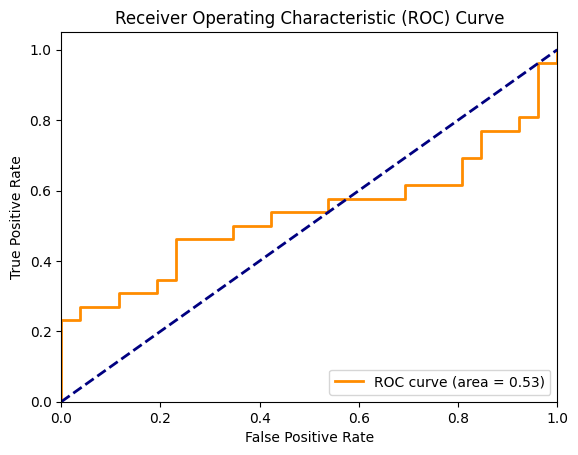


--- Random State: 2 ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Accuracy (RS=2): 0.7500
Logistic Regression - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.49      3763
   macro avg       0.54      0.52      0.45      3763
weighted avg       0.54      0.49      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.33      0.08      0.12        26
           1       0.48      0.85      0.61        26

    accuracy                           0.46        52
   macro avg       0.41      0.46      0.37        52
weighted avg       0.41      0.46      0.37        52

Logistic Regression - RS 2


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


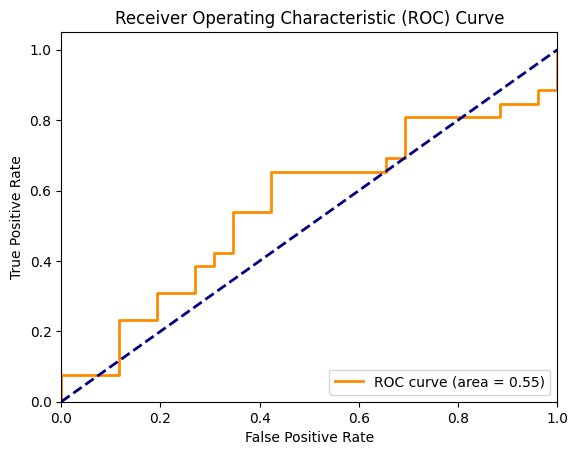


--- Random State: 3 ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Accuracy (RS=3): 0.7885
Logistic Regression - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.49      3763
   macro avg       0.54      0.52      0.45      3763
weighted avg       0.54      0.49      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.60      0.23      0.33        26
           1       0.52      0.85      0.65        26

    accuracy                           0.54        52
   macro avg       0.56      0.54      0.49        52
weighted avg       0.56      0.54      0.49        52

Logistic Regression - RS 3


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


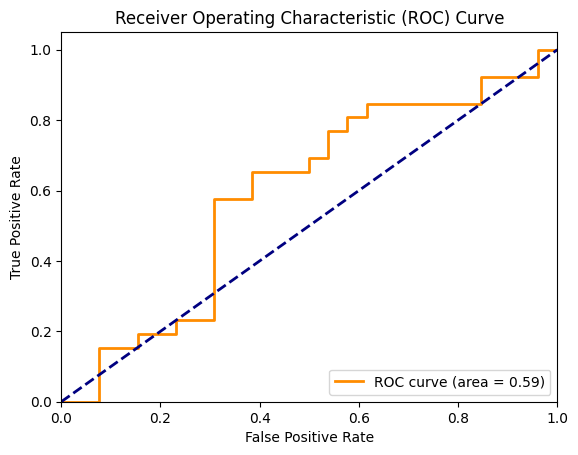


--- Random State: 4 ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Accuracy (RS=4): 0.8462
Logistic Regression - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.49      3763
   macro avg       0.54      0.52      0.45      3763
weighted avg       0.54      0.49      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.58      0.27      0.37        26
           1       0.53      0.81      0.64        26

    accuracy                           0.54        52
   macro avg       0.55      0.54      0.50        52
weighted avg       0.55      0.54      0.50        52

Logistic Regression - RS 4


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


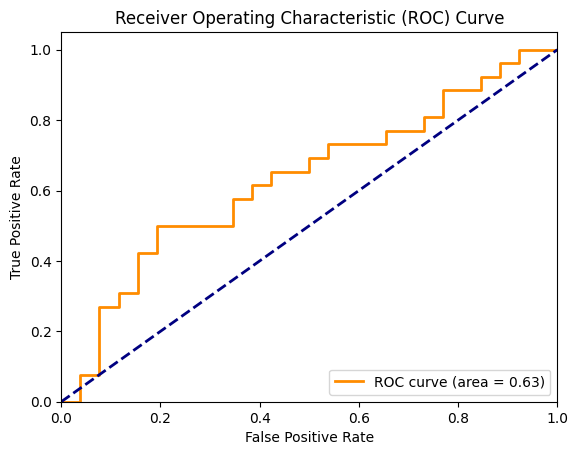


--- Random State: 5 ---
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Accuracy (RS=5): 0.8077
Logistic Regression - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.61      0.20      0.30      2091
           1       0.46      0.84      0.59      1672

    accuracy                           0.49      3763
   macro avg       0.54      0.52      0.45      3763
weighted avg       0.54      0.49      0.43      3763

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.40      0.08      0.13        26
           1       0.49      0.88      0.63        26

    accuracy                           0.48        52
   macro avg       0.44      0.48      0.38        52
weighted avg       0.44      0.48      0.38        52

Logistic Regression - RS 5


C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\base.py:432: UserWarning: X has feature names, but LogisticRegression was fitted without feature names
  warnings.warn(


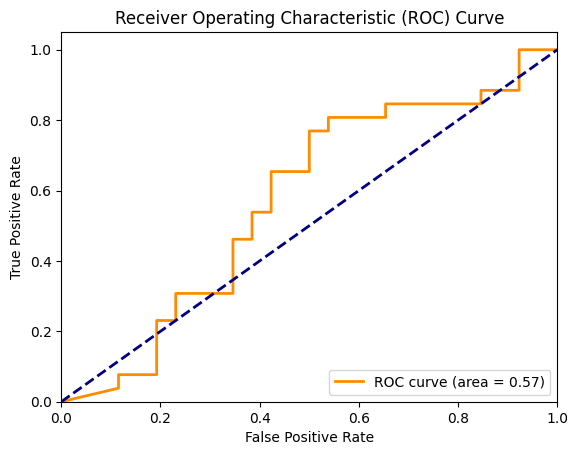


✅ Accuracy media sui 5 split: 0.7808
[0.7115384615384616, 0.75, 0.7884615384615384, 0.8461538461538461, 0.8076923076923077]


In [87]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che df_underfit abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # 26 osservazioni random per ciascuna classe nel test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Training set = resto dei dati
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # SMOTE solo sul training set
    smote = SMOTE(sampling_strategy=0.8, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Standardizzazione
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_resampled)
    X_test_scaled = scaler.transform(X_test)

    # Logistic Regression
    logreg_tuned.fit(X_train_scaled, y_train_resampled)

    # Valutazione
    y_pred = logreg_tuned.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"Logistic Regression - RS {random_state}", logreg_tuned)
    plot_ROC(f"Logistic Regression - RS {random_state}", logreg_tuned)

# Accuracy media finale
mean_accuracy = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_accuracy:.4f}")
print(accuracies)


## DECISION TREE

In [88]:
dtree = DecisionTreeClassifier(max_depth=12, min_samples_split=8, random_state=0, class_weight={0: 1, 1: 2})
parame_grid = {
    'max_depth': [8, 10, 12, 14, 16],  
    'min_samples_split': [2, 4, 8, 16], 
    'criterion': ['gini', 'entropy'],  
    'min_samples_leaf': [1, 2, 4],  
}

In [89]:
dtree_tuned=grid_search(dtree, parame_grid)


--- Random State: 1 ---
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Accuracy (RS=1): 0.9423
Decision Tree - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2091
           1       0.90      1.00      0.95      1881

    accuracy                           0.95      3972
   macro avg       0.95      0.95      0.95      3972
weighted avg       0.95      0.95      0.95      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.93      0.96      0.94        26

    accuracy                           0.94        52
   macro avg       0.94      0.94      0.94        52
weighted avg       0.94      0.94      0.94        52

Decision Tree - RS 1


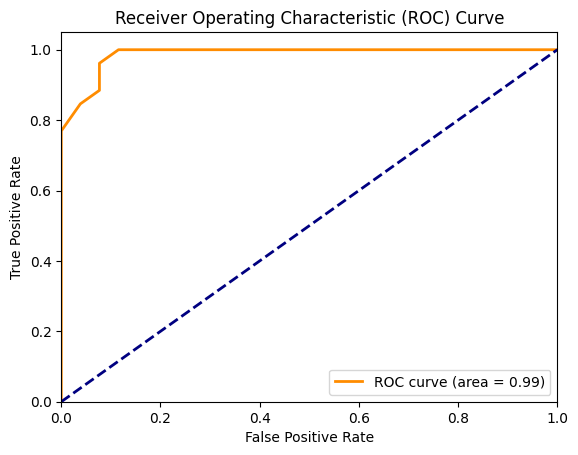


--- Random State: 2 ---
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Accuracy (RS=2): 0.9231
Decision Tree - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2091
           1       0.90      1.00      0.95      1881

    accuracy                           0.95      3972
   macro avg       0.95      0.95      0.95      3972
weighted avg       0.95      0.95      0.95      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.92      0.92      0.92        26

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52

Decision Tree - RS 2


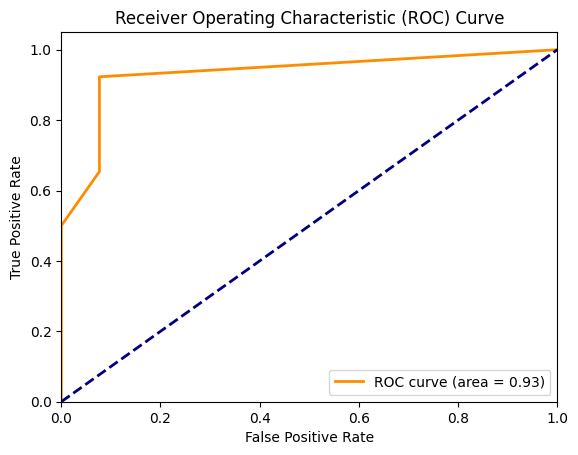


--- Random State: 3 ---
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Accuracy (RS=3): 0.9231
Decision Tree - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2091
           1       0.90      1.00      0.95      1881

    accuracy                           0.95      3972
   macro avg       0.95      0.95      0.95      3972
weighted avg       0.95      0.95      0.95      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.92      0.92      0.92        26
           1       0.92      0.92      0.92        26

    accuracy                           0.92        52
   macro avg       0.92      0.92      0.92        52
weighted avg       0.92      0.92      0.92        52

Decision Tree - RS 3


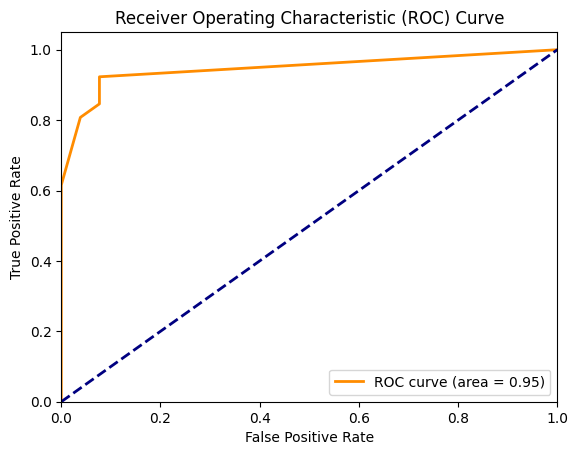


--- Random State: 4 ---
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Accuracy (RS=4): 0.9615
Decision Tree - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2091
           1       0.90      1.00      0.95      1881

    accuracy                           0.95      3972
   macro avg       0.95      0.95      0.95      3972
weighted avg       0.95      0.95      0.95      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.92      0.96        26
           1       0.93      1.00      0.96        26

    accuracy                           0.96        52
   macro avg       0.96      0.96      0.96        52
weighted avg       0.96      0.96      0.96        52

Decision Tree - RS 4


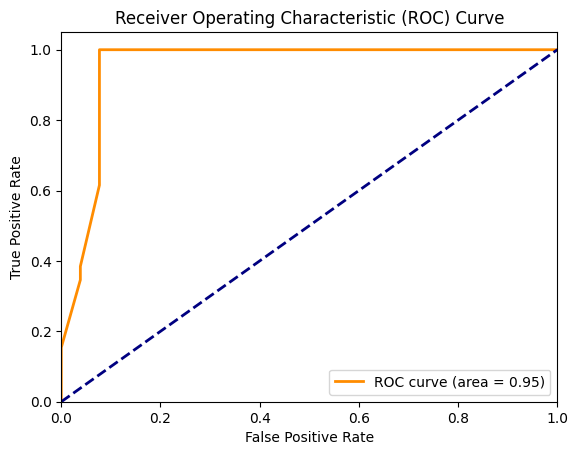


--- Random State: 5 ---
Fitting 5 folds for each of 120 candidates, totalling 600 fits
Accuracy (RS=5): 1.0000
Decision Tree - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.90      0.95      2091
           1       0.90      1.00      0.95      1881

    accuracy                           0.95      3972
   macro avg       0.95      0.95      0.95      3972
weighted avg       0.95      0.95      0.95      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        26
           1       1.00      1.00      1.00        26

    accuracy                           1.00        52
   macro avg       1.00      1.00      1.00        52
weighted avg       1.00      1.00      1.00        52

Decision Tree - RS 5


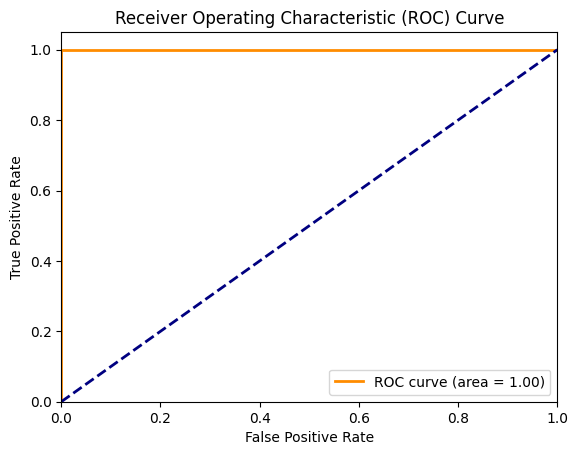


✅ Accuracy media sui 5 split: 0.9500


In [90]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che df_underfit abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione delle classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione 26 osservazioni random per ciascuna classe nel test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Training set = il resto
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # Applica SMOTE
    smote = SMOTE(sampling_strategy=0.9, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # (Opzionale) Normalizzazione
  #  scaler = StandardScaler()
   # X_train_scaled = scaler.fit_transform(X_train_resampled)
    #X_test_scaled = scaler.transform(X_test)
    dtree_tuned.fit(X_train_resampled, y_train_resampled)

    # Valutazione
    y_pred = dtree_tuned.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"Decision Tree - RS {random_state}", dtree_tuned)
    plot_ROC(f"Decision Tree - RS {random_state}", dtree_tuned)

# Accuracy media finale
mean_acc = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_acc:.4f}")


In [115]:
# Stampa i migliori iperparametri trovati
print("Migliori iperparametri trovati:")
print(dtree_tuned.best_params_)

Migliori iperparametri trovati:
{'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2}


## RANDOM FOREST

In [104]:
# Supponiamo che df_new abbia le features (X) e la variabile target (y)
X = df_underfit.drop(columns=['Fraud'])  # Sostituisci 'Fraud' con il nome della colonna della variabile target
y = df_underfit['Fraud']  # Sostituisci 'Fraud' con il nome della colonna della variabile target

# Definizione del modello Random Forest con iperparametri da ottimizzare
rf = RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_split=8, 
                            random_state=0, class_weight={0: 1, 1: 2})

# Definizione della griglia di ricerca per la Random Forest
param_grid = {
    'n_estimators': [15,30, 50, 100],
    'max_depth': [4,6, 8, 10, 12,],
    'min_samples_split': [6,8,10, 14],
    'criterion': ['gini', 'entropy'],
    'min_samples_leaf': [1, 2, 4],
}

In [105]:
# Esegue la ricerca degli iperparametri
rf_tuned = grid_search(rf, param_grid)


--- Random State: 1 ---
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Accuracy (RS=1): 0.8269
Random Forest - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      2091
           1       0.89      1.00      0.94      1881

    accuracy                           0.94      3972
   macro avg       0.94      0.94      0.94      3972
weighted avg       0.95      0.94      0.94      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.79      0.88      0.84        26
           1       0.87      0.77      0.82        26

    accuracy                           0.83        52
   macro avg       0.83      0.83      0.83        52
weighted avg       0.83      0.83      0.83        52

Random Forest - RS 1


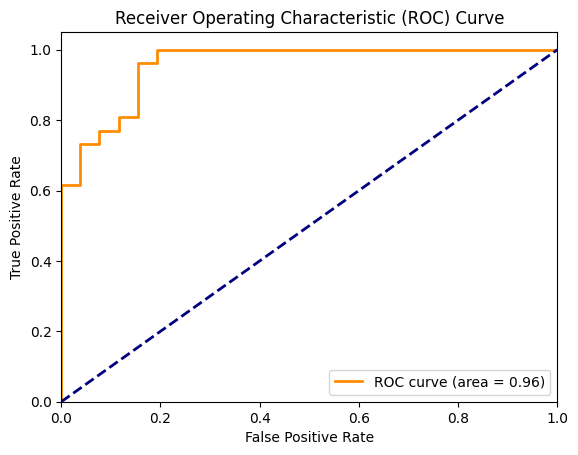


--- Random State: 2 ---
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Accuracy (RS=2): 0.9038
Random Forest - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      2091
           1       0.89      1.00      0.94      1881

    accuracy                           0.94      3972
   macro avg       0.94      0.94      0.94      3972
weighted avg       0.95      0.94      0.94      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.89      0.92      0.91        26
           1       0.92      0.88      0.90        26

    accuracy                           0.90        52
   macro avg       0.90      0.90      0.90        52
weighted avg       0.90      0.90      0.90        52

Random Forest - RS 2


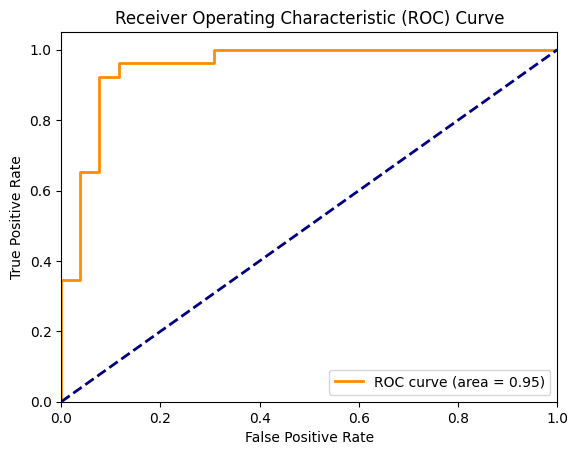


--- Random State: 3 ---
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Accuracy (RS=3): 0.9038
Random Forest - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      2091
           1       0.89      1.00      0.94      1881

    accuracy                           0.94      3972
   macro avg       0.94      0.94      0.94      3972
weighted avg       0.95      0.94      0.94      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.92      0.88      0.90        26
           1       0.89      0.92      0.91        26

    accuracy                           0.90        52
   macro avg       0.90      0.90      0.90        52
weighted avg       0.90      0.90      0.90        52

Random Forest - RS 3


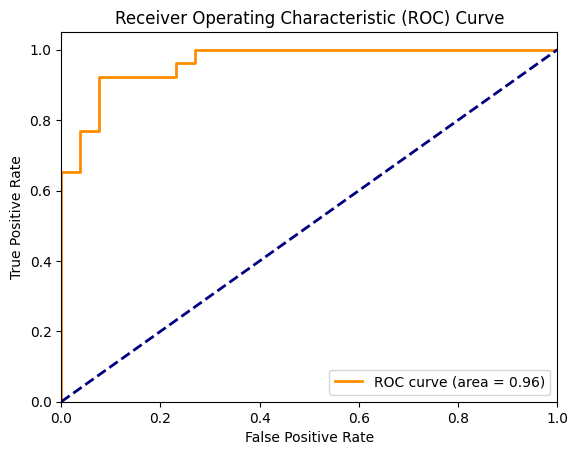


--- Random State: 4 ---
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Accuracy (RS=4): 0.9423
Random Forest - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      2091
           1       0.89      1.00      0.94      1881

    accuracy                           0.94      3972
   macro avg       0.94      0.94      0.94      3972
weighted avg       0.95      0.94      0.94      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.96      0.92      0.94        26
           1       0.93      0.96      0.94        26

    accuracy                           0.94        52
   macro avg       0.94      0.94      0.94        52
weighted avg       0.94      0.94      0.94        52

Random Forest - RS 4


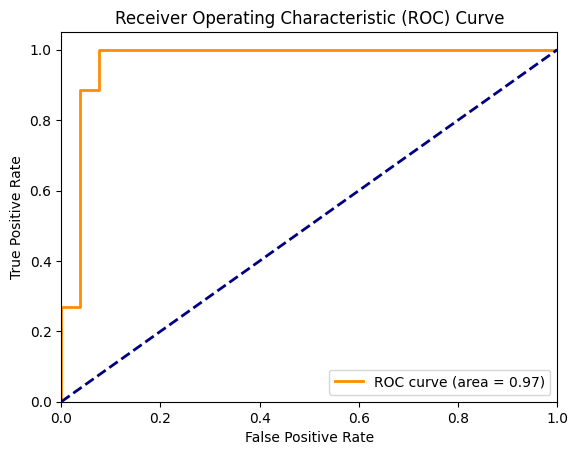


--- Random State: 5 ---
Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Accuracy (RS=5): 0.9423
Random Forest - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94      2091
           1       0.89      1.00      0.94      1881

    accuracy                           0.94      3972
   macro avg       0.94      0.94      0.94      3972
weighted avg       0.95      0.94      0.94      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.93      0.96      0.94        26
           1       0.96      0.92      0.94        26

    accuracy                           0.94        52
   macro avg       0.94      0.94      0.94        52
weighted avg       0.94      0.94      0.94        52

Random Forest - RS 5


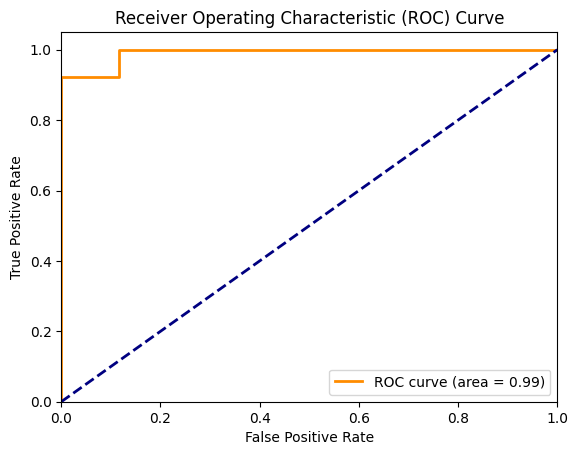


✅ Accuracy media sui 5 split: 0.9038


In [106]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che X e y siano già definiti dal tuo df_underfit
X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione delle classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione casuale di 26 osservazioni per ciascuna classe per il test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Rimozione dal training set
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # Applica SMOTE solo sul training set
    smote = SMOTE(sampling_strategy=0.9, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Allena il modello Random Forest
    rf_tuned.fit(X_train_resampled, y_train_resampled)

    # Valutazione
    y_pred = rf_tuned.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"Random Forest - RS {random_state}", rf_tuned)
    plot_ROC(f"Random Forest - RS {random_state}", rf_tuned)

# Calcolo dell'accuracy media sui 5 split
mean_accuracy = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_accuracy:.4f}")


In [107]:
# Stampa i migliori iperparametri trovati
print("Migliori iperparametri trovati:")
print(rf_tuned.best_params_)

Migliori iperparametri trovati:
{'criterion': 'entropy', 'max_depth': 8, 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 50}


## XGBOOST

In [111]:
# Definizione del modello XGBoost con iperparametri da ottimizzare
xgb = XGBClassifier(n_estimators=100, max_depth=12, learning_rate=0.1, 
                    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=2, 
                    random_state=0, use_label_encoder=False, eval_metric='logloss')

# Definizione della griglia di ricerca per XGBoost
param_grid = {
    'n_estimators': [15, 30, 50, 100],
    'max_depth': [2, 4, 8, 10, 12],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'scale_pos_weight': [1, 1.5, 2],
    'learning_rate': [0.01, 0.1, 0.2]
}


In [112]:
# Esegue la ricerca degli iperparametri
xgb_tuned = grid_search(xgb, param_grid)


--- Random State: 1 ---
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits


C:\Users\mmona\anaconda3\Lib\site-packages\joblib\externals\loky\process_executor.py:700: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Accuracy (RS=1): 0.5000
XGBoost - RS 1
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2091
           1       0.47      1.00      0.64      1881

    accuracy                           0.47      3972
   macro avg       0.24      0.50      0.32      3972
weighted avg       0.22      0.47      0.30      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.50      1.00      0.67        26

    accuracy                           0.50        52
   macro avg       0.25      0.50      0.33        52
weighted avg       0.25      0.50      0.33        52

XGBoost - RS 1


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:09:54] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\

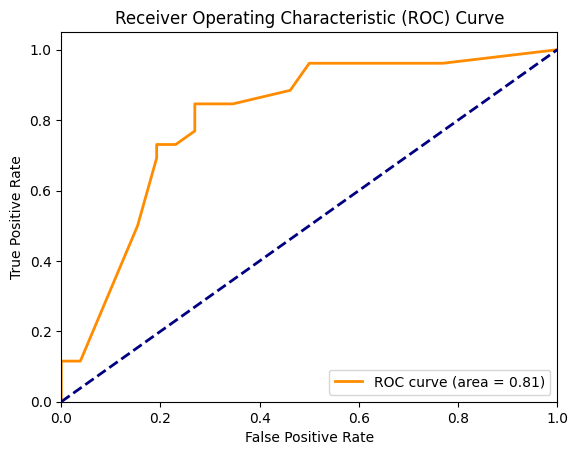


--- Random State: 2 ---
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Accuracy (RS=2): 0.5000
XGBoost - RS 2
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2091
           1       0.47      1.00      0.64      1881

    accuracy                           0.47      3972
   macro avg       0.24      0.50      0.32      3972
weighted avg       0.22      0.47      0.30      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.50      1.00      0.67        26

    accuracy                           0.50        52
   macro avg       0.25      0.50      0.33        52
weighted avg       0.25      0.50      0.33        52

XGBoost - RS 2


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:10:34] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\

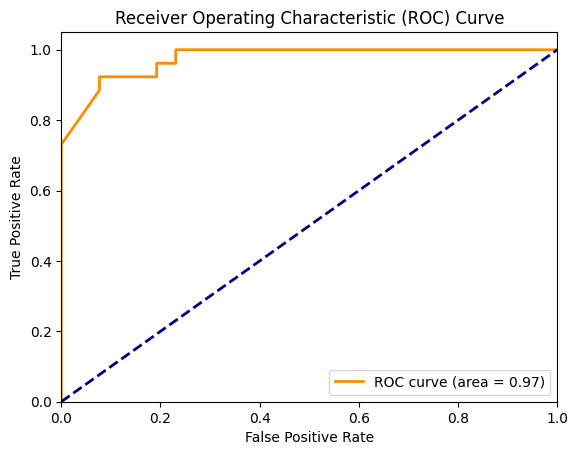


--- Random State: 3 ---
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Accuracy (RS=3): 0.5000
XGBoost - RS 3
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2091
           1       0.47      1.00      0.64      1881

    accuracy                           0.47      3972
   macro avg       0.24      0.50      0.32      3972
weighted avg       0.22      0.47      0.30      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.50      1.00      0.67        26

    accuracy                           0.50        52
   macro avg       0.25      0.50      0.33        52
weighted avg       0.25      0.50      0.33        52

XGBoost - RS 3


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:11:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\

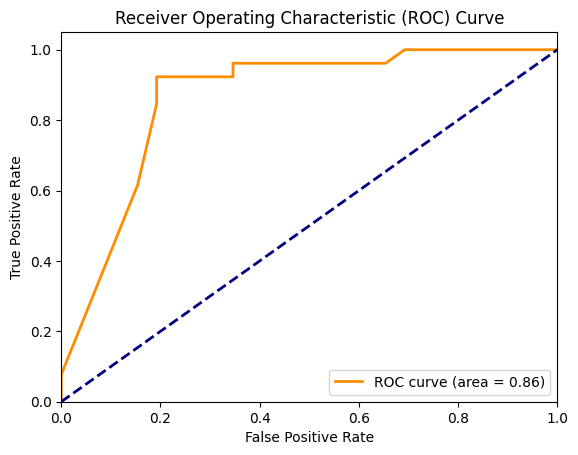


--- Random State: 4 ---
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Accuracy (RS=4): 0.5000
XGBoost - RS 4
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2091
           1       0.47      1.00      0.64      1881

    accuracy                           0.47      3972
   macro avg       0.24      0.50      0.32      3972
weighted avg       0.22      0.47      0.30      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.50      1.00      0.67        26

    accuracy                           0.50        52
   macro avg       0.25      0.50      0.33        52
weighted avg       0.25      0.50      0.33        52

XGBoost - RS 4


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:11:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\

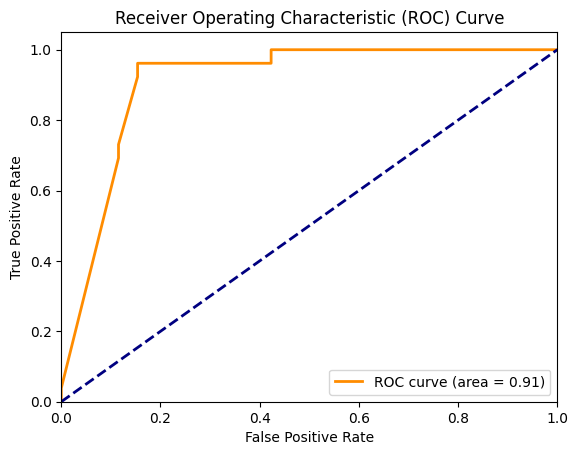


--- Random State: 5 ---
Fitting 5 folds for each of 1620 candidates, totalling 8100 fits
Accuracy (RS=5): 0.5000
XGBoost - RS 5
TRAIN SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      2091
           1       0.47      1.00      0.64      1881

    accuracy                           0.47      3972
   macro avg       0.24      0.50      0.32      3972
weighted avg       0.22      0.47      0.30      3972

TEST SET ---------------------------------
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        26
           1       0.50      1.00      0.67        26

    accuracy                           0.50        52
   macro avg       0.25      0.50      0.33        52
weighted avg       0.25      0.50      0.33        52

XGBoost - RS 5


C:\Users\mmona\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [23:12:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-06abd128ca6c1688d-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\mmona\anaconda3\Lib\site-packages\sklearn\

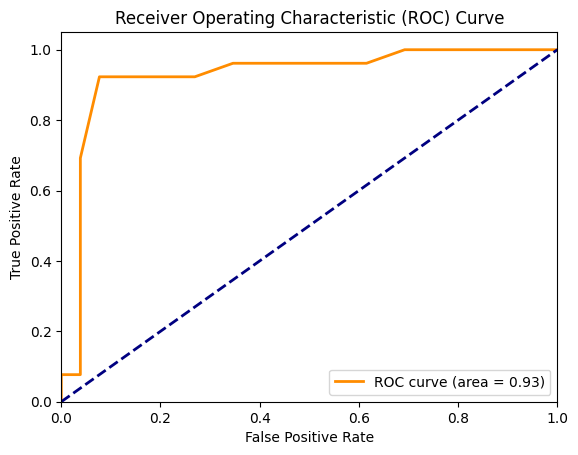


✅ Accuracy media sui 5 split: 0.5000


In [113]:
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd

# Supponiamo che xgb_tuned sia già ottenuto da una precedente grid_search
# Supponiamo anche che df_underfit sia già definito

X = df_underfit.drop(columns=['Fraud'])
y = df_underfit['Fraud']

accuracies = []

for random_state in range(1, 6):
    print(f"\n--- Random State: {random_state} ---")

    # Separazione delle classi
    X_0 = X[y == 0].reset_index(drop=True)
    X_1 = X[y == 1].reset_index(drop=True)
    y_0 = y[y == 0].reset_index(drop=True)
    y_1 = y[y == 1].reset_index(drop=True)

    # Selezione 26 osservazioni random per classe per il test set
    X_0_test = X_0.sample(n=26, random_state=random_state).reset_index(drop=True)
    X_1_test = X_1.sample(n=26, random_state=random_state).reset_index(drop=True)
    y_0_test = y_0.loc[X_0_test.index].reset_index(drop=True)
    y_1_test = y_1.loc[X_1_test.index].reset_index(drop=True)

    X_test = pd.concat([X_0_test, X_1_test], ignore_index=True)
    y_test = pd.concat([y_0_test, y_1_test], ignore_index=True)

    # Il resto è training set
    X_0_train = X_0.drop(X_0_test.index).reset_index(drop=True)
    X_1_train = X_1.drop(X_1_test.index).reset_index(drop=True)
    y_0_train = y_0.drop(X_0_test.index).reset_index(drop=True)
    y_1_train = y_1.drop(X_1_test.index).reset_index(drop=True)

    X_train = pd.concat([X_0_train, X_1_train], ignore_index=True)
    y_train = pd.concat([y_0_train, y_1_train], ignore_index=True)

    # Applica SMOTE
    smote = SMOTE(sampling_strategy=0.9, random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # Addestramento del modello XGBoost ottimizzato
    xgb_tuned.fit(X_train_resampled, y_train_resampled)

    # Valutazione
    y_pred = xgb_tuned.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)

    print(f"Accuracy (RS={random_state}): {acc:.4f}")
    print_classification_reports(f"XGBoost - RS {random_state}", xgb_tuned)
    plot_ROC(f"XGBoost - RS {random_state}", xgb_tuned)

# Calcolo dell'accuracy media
mean_accuracy = np.mean(accuracies)
print(f"\n✅ Accuracy media sui 5 split: {mean_accuracy:.4f}")


# 6. INTERPRETABILITA'

C:\Users\mmona\AppData\Local\Temp\ipykernel_19364\2005817638.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_importances_series.values, y=feat_importances_series.index, palette='viridis')


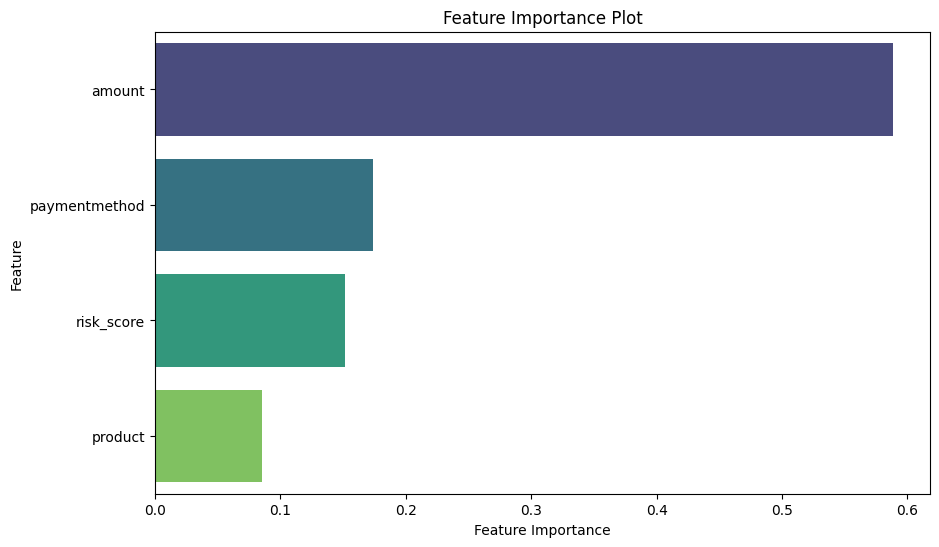

In [114]:
best_model = dtree_tuned.best_estimator_
feat_importances = best_model.feature_importances_

# Create a pandas Series with feature importances
feat_importances_series = pd.Series(feat_importances, index=X_train.columns)

# Sort feature importances in descending order
feat_importances_series = feat_importances_series.sort_values(ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x=feat_importances_series.values, y=feat_importances_series.index, palette='viridis')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Feature Importance Plot')
plt.show()